# Diamond Creek ETF Arbitrage Fund — Strategy Backtest

**Version 2** · Full universe (300 leveraged pairs + 39 inverse ETFs) · Per-ETF borrow rates from IBKR FTP

---

## Strategy Summary

The fund captures **volatility decay** from leveraged and inverse ETFs. For each pair we:
- **Short** the leveraged ETF (which bleeds value from daily rebalancing drag)
- **Long** the underlying (as a delta hedge, sized by 1/|β|)

Position sizes are rebuilt from scratch every rebalance using live rolling analytics and a decay-score weighting model.

---

## Assumptions & Simplifications

This backtest makes a number of assumptions. Understanding where it departs from reality is critical for interpreting the results.

### ✅ What matches the live system faithfully

| Component | Implementation |
|-----------|---------------|
| **Pair universe** | All 300+ pairs from `daily_screener.py`, deduplicated identically to `build_full_universe()` |
| **Position sizing** | `decay_score_weights()` with `eq_blend=0.5`, `borrow_aversion=3`, `margin_efficiency_power=0.5`, max-name-weight caps (8% core / 20% WL) with redistribution |
| **Hedge ratio** | `1/|β|` per pair; `long = gross / (1 + hr)`, `short = −hr × long` |
| **Sleeve allocation** | 88% core (|β| ≥ 1.5) / 12% whitelist, with reallocation if one sleeve is empty |
| **Rebalance cadence** | 5 trading-day calendar rebalance (weekly) |
| **Execution timing** | PnL computed on prior-day positions before rebalance — no lookahead |
| **Flow program** | $1,300/week split Mon/Thu across 13 inverse ETFs per fixed weights |
| **Commission model** | IBKR Pro: $0.005/share, $1 minimum, 0.5% of trade value maximum |
| **Fee structure** | 2% management (daily accrual) / 20% incentive above 8% hurdle / full GP catch-up |

### ⚠️ Assumptions and known gaps

| Assumption | Impact | Direction of bias |
|------------|--------|-------------------|
| **Static borrow rates** | We fetch *current* IBKR FTP rates and apply them to the entire history. In reality, borrow costs evolve over time — many newer ETFs had higher borrow at launch. | **Likely understates** early-period borrow costs for names that were expensive to borrow in 2023 but cheap today. Also **overstates** for names that are expensive now but were cheap historically. Net direction is ambiguous. |
| **No borrow availability filter** | The live system skips shorts when FTP `available=0`. The backtest assumes all shorts can be filled at any time. | **Overstates** returns — some high-decay pairs may have been unshoratable in practice. |
| **Flat slippage (20 bps)** | Actual slippage depends on ADV, spread width, and order size. Small-cap leveraged ETFs with $1M ADV would experience more slippage on a $50K order than a $500M ADV name. | **Understates** costs for illiquid names, **overstates** for liquid names. Net likely **slightly optimistic**. |
| **Pair ramp effect** | Many ETFs in the universe launched in 2024–2025. The backtest only trades pairs when both legs have sufficient price history (60+ days for beta). Early periods show fewer pairs, later periods show more. | **Inflates** apparent recent performance relative to early period. CAGR from 2023-01-01 includes a "ramp-up" where capital was underdeployed. |
| **No screening filter in backtest** | The live screener applies `include_for_algo`, purgatory logic, borrow caps, and stale-ETF filters. The backtest only filters on β > 0 and |β| ≥ 1.5 for core. | **Overstates** pair count — some pairs the live system would exclude (high borrow, purgatory, failed IBKR contract check) are included here. |
| **Yahoo Finance adjusted close** | Price data comes from Yahoo's `adjclose` field. This handles splits and dividends but can have errors — particularly for leveraged ETFs where split adjustments sometimes lag. The live system uses `_clean_split_artifacts()` which is not replicated here. | Could introduce **spurious vol spikes** that distort beta/decay estimates for specific ETFs. |
| **No margin constraint** | The live system is margin-constrained (IBKR Reg-T / portfolio margin). The backtest assumes unlimited leverage at 4×. In practice, 3× leveraged short positions require 90% maintenance margin. | **Overstates** achievable gross exposure. The 4× target may not always be fully deployable. |
| **No intraday execution dynamics** | The backtest assumes fills at closing price ± slippage. The live system uses adaptive market orders with retry logic, partial fills, and short-block handling. | Generally **neutral** — closing price ± 20 bps is a reasonable approximation of VWAP for most names. |
| **Single beta window** | Rolling 252-day OLS beta. The live system also uses this, but the backtest doesn't handle sign-mismatch imputation or short-history fallback to expected leverage. | Minor — affects only new ETFs in their first months. |
| **No realized decay weekly frequency alignment** | Realized decay is computed on weekly (Friday-to-Friday) log returns, matching the live system. However, the blended decay trust ramp uses an expanding count that may slightly overweight realized decay in the backtest vs. live. | Minor — direction is ambiguous. |

### 🔴 What is NOT modeled

- **Margin calls / forced liquidation** — if drawdown exceeds margin, IBKR would force-close positions
- **Corporate actions beyond splits** — mergers, delistings mid-backtest, ticker changes
- **Tax implications** — short-term gains, wash sales, dividend withholding on short positions
- **Funding rate / cash drag** — interest earned on cash, interest charged on margin debit
- **Regulatory risk** — SEC short-sale restrictions (uptick rule, Reg SHO threshold lists)

## Cell 1 — Setup

In [10]:
# !pip install requests pandas numpy pyyaml -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import time
import ftplib
import io
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Dict, List, Tuple, Set

TRADING_DAYS = 252
print("Imports OK")

Imports OK


## Cell 2 — Strategy Configuration

Edit these parameters to change the backtest behavior. All values mirror `strategy_config.yml`.

In [11]:
# ── Strategy parameters ──────────────────────────────────────────
CFG = {
    "capital_usd":          5_000_000,
    "gross_leverage":       4,
    "start_date":           "2023-01-01",
    "rebal_days":           5,          # weekly calendar rebalance
    "slippage_bps":         20,
    "ibkr_comm_per_share":  0.005,
    "ibkr_comm_min":        1.00,
    "ibkr_comm_max_pct":    0.005,      # 0.5% of trade value
    "fallback_borrow_rate": 0.005,      # used when FTP unavailable / ETF not in FTP
    "beta_window":          252,
    "min_beta_days":        60,
    "realized_trust_days":  252,
    "min_trade_usd":        200,
    "core_weight":          0.88,
    "wl_weight":            0.12,
    "core_beta_min":        1.50,
    "enable_flow":          True,
    "flow_usd_per_week":    1300,
    "flow_schedule_days":   [0, 3],     # Mon=0, Thu=3
    # Fee layer (applied in a separate cell)
    "mgmt_fee":             0.02,
    "incentive_fee":        0.20,
    "hurdle_rate":          0.08,
    # FTP control
    "skip_ftp":             False,      # set True to skip IBKR FTP and use flat fallback rate
}

CORE_WEIGHTING = {"eq_blend": 0.5, "max_name_weight": 0.08,
                  "borrow_aversion": 3, "margin_efficiency_power": 0.5}
WL_WEIGHTING   = {"eq_blend": 0.50, "max_name_weight": 0.20,
                  "borrow_aversion": 3, "margin_efficiency_power": 0.5}

BLACKLIST = {"JPM", "BRK-B", "AXP", "APLD"}
WL_ETFS   = {"MTYY","MAAY","FBYY","XBTY","NFLW","HOOW","MARO",
              "TSLO","MSFW","PLTW","MSTW"}
FLOW_WEIGHTS = {"SDS":0.22,"EWV":0.18,"SQQQ":0.15,"TQQY":0.07,
                "LABD":0.08,"SOXS":0.05,"FAZ":0.08,"DUST":0.03,
                "ZSL":0.01,"TSLQ":0.04,"TSYY":0.02,"NVDQ":0.04,"NVYY":0.03}

norm_sym = lambda x: str(x).strip().upper().replace(".", "-")

print(f"Capital: ${CFG['capital_usd']:,}  |  Leverage: {CFG['gross_leverage']}x  |  "
      f"Rebal: every {CFG['rebal_days']}d  |  Start: {CFG['start_date']}")
print(f"Core: {CFG['core_weight']:.0%} (β≥{CFG['core_beta_min']})  |  "
      f"Whitelist: {CFG['wl_weight']:.0%} ({len(WL_ETFS)} ETFs)  |  "
      f"Flow: ${CFG['flow_usd_per_week']:,}/wk")

Capital: $5,000,000  |  Leverage: 4x  |  Rebal: every 5d  |  Start: 2023-01-01
Core: 88% (β≥1.5)  |  Whitelist: 12% (11 ETFs)  |  Flow: $1,300/wk


## Cell 3 — Pair Universe

Complete universe from `daily_screener.py`: 300 leveraged pairs + 39 inverse ETFs after deduplication.

In [12]:
leverage_pairs = [
    ("AAPU","AAPL"),("AMUU","AMD"),("AMZU","AMZN"),("ASMU","ASML"),
    ("AVL","AVGO"),("BOEU","BA"),("BABU","BABA"),("BRKU","BRK-B"),
    ("CONX","COIN"),("CSCL","CSCO"),("FRDU","F"),("GGLL","GOOGL"),
    ("HODU","HOOD"),("LINT","INTC"),("ELIL","LLY"),("LMTL","LMT"),
    ("METU","META"),("MRVU","MRVL"),("MSFU","MSFT"),("MUU","MU"),
    ("NFXL","NFLX"),("NVDU","NVDA"),("ORCU","ORCL"),("PALU","PANW"),
    ("PLTU","PLTR"),("QCMU","QCOM"),("SHPU","SHOP"),("SOFA","SOFI"),
    ("TSLL","TSLA"),("TSMX","TSM"),("XOMX","XOM"),
    ("YINN","FXI"),("MEXX","EWW"),("KORU","EWY"),("HIBL","SPY"),
    ("LABU","XBI"),("SOXL","SOXX"),
    ("CHAU","ASHR"),("CWEB","KWEB"),("ERX","XLE"),("NUGT","GDX"),
    ("JNUG","GDXJ"),("GUSH","XOP"),("URAA","URA"),
]

leverage_pairs_leverageshares = [
    ("AALG","AAL"),("ABNG","ABNB"),("ADBG","ADBE"),("AMDG","AMD"),
    ("ARMG","ARM"),("ASMG","ASML"),("AVGG","AVGO"),("BAIG","BBAI"),
    ("BEG","BE"),("BIDG","BIDU"),("BLSG","BLSH"),("BMNG","BMNR"),
    ("BOEG","BA"),("BULG","BULL"),("CIFG","CIFR"),("CMGG","CMG"),
    ("CNCG","CNC"),("COIG","COIN"),("COTG","COST"),("CRCG","CRCL"),
    ("CRMG","CRM"),("CRWG","CRWV"),("DUOG","DUOL"),("FIGG","FIG"),
    ("FUTG","FUTU"),("GEMG","GEMI"),("GEVG","GEV"),("GLGG","GLXY"),
    ("GRAG","GRAB"),("HOOG","HOOD"),("IREG","IREN"),("KLAG","KLAC"),
    ("LACG","LAC"),("LULG","LULU"),("MPG","MP"),("NBIG","NBIS"),
    ("NEMG","NEM"),("NETG","NET"),("NIOG","NIO"),("NUG","NU"),
    ("NVDG","NVDA"),("OKTG","OKTA"),("OPEG","OPEN"),("OSCG","OSCR"),
    ("PANG","PANW"),("PBRG","PBR"),("PLTG","PLTR"),("PYPG","PYPL"),
    ("RTXG","RTX"),("SATG","SATS"),("SBU","SBUX"),("SNAG","SNAP"),
    ("SPOG","SPOT"),("TERG","TER"),("TSLG","TSLA"),("TSMG","TSM"),
    ("UNHG","UNH"),("UPSG","UPS"),("VALG","VALE"),("XYZG","XYZ"),
]

new_pairs = [
    ("MSTU","MSTR"),("NVDX","NVDA"),("TSLT","TSLA"),("BTCL","IBIT"),
    ("ETU","ETHA"),("CCUP","CRCL"),("CRWU","CRWV"),("AAPX","AAPL"),
    ("GOOX","GOOGL"),("MSFX","MSFT"),("NFLU","NFLX"),("ROBN","HOOD"),
    ("ARMU","ARM"),("DJTU","DJT"),("RBLU","RBLX"),("SNOU","SNOW"),
    ("SMUP","SMR"),("DKUP","DKNG"),("BULU","BULL"),("GLXU","GLXY"),
    ("AFRU","AFRM"),("AXUP","AXON"),("KTUP","KTOS"),("TTDU","TTD"),
    ("BKNU","BKNG"),("PXIU","UPXI"),("BMNU","BMNR"),("SBTU","SBET"),
    ("CIFU","CIFR"),("SOLX","GSOL"),("XRPK","XRPZ"),("XRPT","XRPZ"),
    ("GMEU","GME"),("APLX","APLD"),("APPX","APP"),("ARCX","ACHR"),
    ("ASTX","ASTS"),("AURU","AUR"),("BEX","BE"),("BLSX","BLSH"),
    ("CEGX","CEG"),("CELT","CELH"),("CLSX","CLSK"),("COZX","CORZ"),
    ("CRDU","CRDO"),("CSEX","CLS"),("CWVX","CRWV"),("DASX","DASH"),
    ("DOGD","DDOG"),("ENPX","ENPH"),("FLYT","FLY"),("GEVX","GEV"),
    ("IREX","IREN"),("JOBX","JOBY"),("LABX","ALAB"),("LRCU","LRCX"),
    ("LYFX","LYFT"),("MDBX","MDB"),("NEBX","NBIS"),("NETX","NET"),
    ("NNEX","NNE"),("NVTX","NVTS"),("NWMX","NEM"),("OKTX","OKTA"),
    ("OPEX","OPEN"),("PONX","PONY"),("QBTX","QBTS"),("QSX","QS"),
    ("QUBX","QUBT"),("RGTU","RGTI"),("SMU","SMR"),("SNPX","SNPS"),
    ("SRPU","SRPT"),("TARK","ARKK"),("TEMT","TEM"),("UNX","U"),
    ("UPSX","UPST"),("VOYX","VOYG"),("WULX","WULF"),("CRMU","CRML"),
    ("UECG","UEC"),("DNNG","DNN"),("RCAX","RCAT"),("RDWU","RDW"),
    ("OKLL","OKLO"),("GDXU","GDX"),("MRNX","MRNA"),("ZETX","ZETA"),
    ("LITX","LITE"),("SNXX","SNDX"),("WDCX","WDC"),("LNOK","NOK"),
    ("USGG","USAR"),("ONDG","ONDS"),("PLUL","PLUG"),("ALBG","ALB"),
    ("UUUG","UUUU"),("HUTG","HUT"),("XPEG","XPEV"),("ORLG","ORLY"),
    ("LUNL","LUNR"),("RKTL","RKT"),("EOSU","EOSE"),("BTFL","BITF"),
    ("FGRU","FIGR"),("APHU","APH"),("COPZ","COPX"),("LEUX","LEU"),
    ("COHX","COHR"),("AXPG","AXP"),("FCXG","FCX"),("GLWG","GLW"),
    ("SNDU","SNDK"),("PAAU","PAAS"),
    ("BITX","IBIT"),("ETHU","ETHA"),("XXRP","XRPZ"),
]

proshares_pairs_levered = [
    ("CRCA","CRCL"),("NVDB","NVDA"),("PLTA","PLTR"),("TSLI","TSLA"),
    ("COIA","COIN"),("BITU","IBIT"),("ETHT","ETHA"),("UXRP","XRPZ"),
    ("SOLT","SOEZ"),
]

graniteshares_pairs_leveraged = [
    ("TSLR","TSLA"),("AAPB","AAPL"),("AMDL","AMD"),("AMZZ","AMZN"),
    ("AVGU","AVGO"),("BABX","BABA"),("BULX","BULL"),("CONL","COIN"),
    ("CRWL","CRWD"),("DLLL","DELL"),("ETRL","ETOR"),("GOU","GOOGL"),
    ("INTW","INTC"),("IONL","IONQ"),("ISUL","ISRG"),("LCDL","LCID"),
    ("MRAL","MARA"),("FBL","META"),("MVLL","MRVL"),("MSFL","MSFT"),
    ("MSTP","MSTR"),("MULL","MU"),("NBIL","NBIS"),("NOWL","NOW"),
    ("NVDL","NVDA"),("PDDL","PDD"),("PTIR","PLTR"),("QCML","QCOM"),
    ("RDTL","RDDT"),("RVNL","RIVN"),("SMCL","SMCI"),("TSMU","TSM"),
    ("UBRL","UBER"),("VRTL","VRT"),("AMYY","AMD"),("AZYY","AMZN"),
    ("BBYY","BABA"),("XBTY","IBIT"),("COYY","COIN"),("NUGY","GDX"),
    ("HMYY","HIMS"),("HOYY","HOOD"),("IOYY","IONQ"),("MAAY","MARA"),
    ("FBYY","META"),("MTYY","MSTR"),("NVYY","NVDA"),("PLYY","PLTR"),
    ("QBY","QBTS"),("TQQY","QQQ"),("RGYY","RGTI"),("RTYY","RIOT"),
    ("SEMY","SOXX"),("SMYY","SMCI"),("YSPY","SPY"),("TSYY","TSLA"),
]

leverage_pairs_capped_accel = [
    ("COIO","COIN"),("MSOO","MSTR"),("NVDO","NVDA"),
    ("PLOO","PLTR"),("TSLO","TSLA"),
]

covered_call_pairs = [
    ("QYLD","QQQ"),("QYLG","QQQ"),("QQQX","QQQ"),("JEPQ","QQQ"),
    ("XYLD","SPY"),("XYLG","SPY"),("JEPI","SPY"),("SPYI","SPY"),
    ("RYLD","IWM"),
]

BENCHMARK_MAP = {
    "SPX":"SPY","NDX":"QQQ","DJIA":"DIA","RUT":"IWM",
    "SOX":"SOXX","FIN":"XLF","BIOTECH":"XBI","TECH":"XLK",
    "WTI":"USO","TSLA":"TSLA","MSTR":"MSTR","NVDA":"NVDA",
    "BTC":"IBIT","ETH":"ETHA","CRCL":"CRCL","CRWV":"CRWV",
    "GDX":"GDX","SLV":"SLV","XLE":"XLE","XOP":"XOP",
    "TLT":"TLT","MSCIJP":"EWJ","APLD":"APLD","CLSK":"CLSK",
}

INVERSE_ETF_UNIVERSE = [
    ("SDS",-2,"SPX"),("QID",-2,"NDX"),("DXD",-2,"DJIA"),("TWM",-2,"RUT"),
    ("SCO",-2,"WTI"),("MSTZ",-2,"MSTR"),("NVDQ",-2,"NVDA"),("BTCZ",-2,"BTC"),
    ("ETHD",-2,"ETH"),("CRCD",-2,"CRCL"),("CORD",-2,"CRWV"),("TSLQ",-2,"TSLA"),
    ("ZSL",-2,"SLV"),("SQQQ",-3,"NDX"),("SPXS",-3,"SPX"),("TZA",-3,"RUT"),
    ("SOXS",-3,"SOX"),("FAZ",-3,"FIN"),("LABD",-3,"BIOTECH"),
    ("TECS",-3,"TECH"),("SDOW",-3,"DJIA"),("DUST",-3,"GDX"),
    ("TTXD",-2,"TECH"),("TSXD",-2,"SOX"),("WEBS",-3,"TECH"),("FNGD",-3,"TECH"),
    ("REW",-2,"TECH"),("SKF",-2,"FIN"),("SPXU",-3,"SPX"),
    ("DUG",-2,"XLE"),("DRIP",-2,"XOP"),("TMV",-3,"TLT"),
    ("TBT",-2,"TLT"),("TBX",-2,"TLT"),("NVDS",-1.5,"NVDA"),
    ("EWV",-2,"MSCIJP"),("APLZ",-2,"APLD"),
    ("HIBS",-3,"SPX"),("CLSZ",-2,"CLSK"),
]

# ── Build deduplicated universe (matches daily_screener.build_full_universe) ──
existing_etfs = {e for e, _ in leverage_pairs}
combined = list(leverage_pairs) + [(e,u) for e,u in new_pairs if e not in existing_etfs]

def _dedupe(pairs):
    seen, out = set(), []
    for e, u in pairs:
        en = norm_sym(e)
        if en not in seen:
            seen.add(en)
            out.append((en, norm_sym(u)))
    return out

all_levered = _dedupe(combined + leverage_pairs_leverageshares
    + leverage_pairs_capped_accel + proshares_pairs_levered
    + graniteshares_pairs_leveraged)

lev_etfs = {e for e, _ in all_levered}
cc = [(norm_sym(e), norm_sym(u)) for e,u in covered_call_pairs if norm_sym(e) not in lev_etfs]
ALL_PAIRS = all_levered + cc

seen_all = {e for e, _ in ALL_PAIRS}
INV_MAP = {}
for etf, lev, group in INVERSE_ETF_UNIVERSE:
    en = norm_sym(etf)
    if en not in seen_all:
        seen_all.add(en)
        bench = BENCHMARK_MAP.get(group)
        if bench:
            INV_MAP[en] = {"und": norm_sym(bench), "lev": lev}

ETF_TO_UND = {e: u for e, u in ALL_PAIRS}
ALL_TICKERS = set()
for e, u in ALL_PAIRS: ALL_TICKERS |= {e, u}
for e, info in INV_MAP.items(): ALL_TICKERS |= {e, info["und"]}

print(f"Leveraged + CC pairs: {len(ALL_PAIRS)}")
print(f"Inverse ETFs: {len(INV_MAP)}")
print(f"Total unique tickers: {len(ALL_TICKERS)}")

Leveraged + CC pairs: 300
Inverse ETFs: 39
Total unique tickers: 545


## Cell 4 — Fetch IBKR Borrow Rates

Connects to IBKR FTP to get current per-ETF borrow fee rates. These are applied as:
1. **Decay-score input**: `blended_decay − borrow_aversion × borrow_current`
2. **Daily short-carry cost**: `short_notional × rate / 252` per position

⚠️ **Assumption**: Current rates applied to entire backtest history. Set `CFG["skip_ftp"] = True` to use a flat 0.5% fallback instead.

In [13]:
FTP_HOST = os.getenv("IBKR_FTP_HOST") or "ftp2.interactivebrokers.com"
FTP_USER = os.getenv("IBKR_FTP_USER") or "shortstock"
FTP_PASS = os.getenv("IBKR_FTP_PASS") or ""
BORROW_CACHE = Path("data/borrow_cache.csv")

all_etf_syms = list({e for e, _ in ALL_PAIRS} | set(INV_MAP.keys()))

if CFG.get("skip_ftp"):
    print(f"[FTP] Skipped — using flat {CFG['fallback_borrow_rate']:.2%}")
    BORROW_MAP = {e: CFG["fallback_borrow_rate"] for e in all_etf_syms}
else:
    BORROW_MAP = {}
    raw_df = None
    for attempt in range(1, 4):
        try:
            print(f"[FTP] Connecting (attempt {attempt}/3)...")
            ftp = ftplib.FTP(timeout=30)
            ftp.connect(FTP_HOST, 21)
            ftp.login(user=FTP_USER, passwd=FTP_PASS)
            ftp.set_pasv(True)
            buf = io.BytesIO()
            ftp.retrbinary("RETR usa.txt", buf.write)
            try: ftp.quit()
            except: pass
            text = buf.getvalue().decode("utf-8", errors="ignore")
            lines = [ln for ln in text.splitlines() if ln.strip()]
            hdr_idx = next(i for i, ln in enumerate(lines) if ln.startswith("#SYM|"))
            hdr = [c.strip().lstrip("#").lower() for c in lines[hdr_idx].split("|")]
            data = lines[hdr_idx + 1:]
            raw_df = pd.read_csv(io.StringIO("\n".join(data)), sep="|", header=None, engine="python")
            raw_df = raw_df.iloc[:, :min(len(hdr), raw_df.shape[1])]
            raw_df.columns = hdr[:raw_df.shape[1]]
            print(f"[FTP] Parsed {len(raw_df)} rows")
            BORROW_CACHE.parent.mkdir(parents=True, exist_ok=True)
            raw_df.to_csv(BORROW_CACHE, index=False)
            break
        except Exception as e:
            if attempt < 3: time.sleep(2**attempt)
            else:
                print(f"[FTP] Failed: {e}")
                if BORROW_CACHE.exists():
                    raw_df = pd.read_csv(BORROW_CACHE)
                    print(f"[FTP] Loaded cache ({len(raw_df)} rows)")

    if raw_df is not None:
        def _pr(x):
            try: return float(str(x).replace("%","").strip()) / 100
            except: return np.nan
        raw_df["sym"] = raw_df["sym"].astype(str).str.upper().str.strip()
        raw_df["net"] = (raw_df["feerate"].map(_pr) - raw_df["rebaterate"].map(_pr)).clip(lower=0)
        agg = raw_df.groupby("sym")["net"].max()
        found = missing = 0
        for e in all_etf_syms:
            if e in agg.index and pd.notna(agg[e]):
                BORROW_MAP[e] = float(agg[e])
                found += 1
            else:
                BORROW_MAP[e] = CFG["fallback_borrow_rate"]
                missing += 1
        print(f"[FTP] {found} from FTP, {missing} fallback")
        nz = [v for v in BORROW_MAP.values() if v > 0.001]
        if nz: print(f"[FTP] Borrow: median={np.median(nz):.2%} mean={np.mean(nz):.2%} max={max(nz):.2%}")
    else:
        BORROW_MAP = {e: CFG["fallback_borrow_rate"] for e in all_etf_syms}
        print(f"[FTP] No data — flat {CFG['fallback_borrow_rate']:.2%}")

[FTP] Connecting (attempt 1/3)...


[FTP] Parsed 18845 rows
[FTP] 303 from FTP, 36 fallback
[FTP] Borrow: median=14.31% mean=22.97% max=335.49%


## Cell 5 — Download Price Data

~545 tickers via Yahoo Finance v8 API (fallback to `yfinance` library). Takes 2–4 minutes.

In [14]:
def download_price(ticker, period="5y"):
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}"
    params = {"range": period, "interval": "1d", "events": "div,splits"}
    headers = {"User-Agent": "Mozilla/5.0 Chrome/120.0.0.0"}
    try:
        resp = requests.get(url, params=params, headers=headers, timeout=15)
        resp.raise_for_status()
        d = resp.json()["chart"]["result"][0]
        idx = pd.to_datetime(d["timestamp"], unit="s", utc=True).tz_convert("America/New_York").normalize()
        s = pd.Series(d["indicators"]["adjclose"][0]["adjclose"], index=idx, name=ticker, dtype=float).dropna()
        return s[~s.index.duplicated(keep="last")]
    except Exception:
        try:
            import yfinance as yf
            df = yf.download(ticker, period=period, progress=False, auto_adjust=True)
            if not df.empty:
                # yfinance >=0.2.36 returns MultiIndex columns — flatten
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(0)
                s = df["Close"].squeeze()
                if isinstance(s, pd.DataFrame): s = s.iloc[:,0]
                s = pd.Series(s.values, index=s.index, name=ticker, dtype=float)
                return s.dropna()
        except: pass
        return pd.Series(dtype=float, name=ticker)

print(f"Downloading {len(ALL_TICKERS)} tickers...")
t0 = time.monotonic()
PRICES = {}
with ThreadPoolExecutor(max_workers=8) as pool:
    futs = {pool.submit(download_price, t, "5y"): t for t in sorted(ALL_TICKERS)}
    for i, f in enumerate(as_completed(futs)):
        t = futs[f]
        try:
            s = f.result()
            if not s.empty and len(s) > 30:
                PRICES[norm_sym(t)] = s
        except: pass
        if (i+1) % 50 == 0: print(f"  {i+1}/{len(ALL_TICKERS)} [{time.monotonic()-t0:.0f}s]")

print(f"Got {len(PRICES)}/{len(ALL_TICKERS)} [{time.monotonic()-t0:.1f}s]")

# ── Cleanup: force Series + strip timezones ──
# Yahoo v8 returns tz-aware indices, yfinance returns tz-naive + DataFrames.
# Normalize everything to tz-naive pd.Series so nothing blows up downstream.
cleaned = 0
for sym in list(PRICES.keys()):
    v = PRICES[sym]
    changed = False
    if isinstance(v, pd.DataFrame):
        if isinstance(v.columns, pd.MultiIndex):
            v.columns = v.columns.get_level_values(0)
        v = v.iloc[:, 0]
        changed = True
    if hasattr(v.index, 'tz') and v.index.tz is not None:
        v = v.tz_localize(None)
        changed = True
    if changed:
        PRICES[sym] = v
        cleaned += 1
print(f"Cleaned {cleaned}/{len(PRICES)} series (forced tz-naive pd.Series)")

AVAIL_PAIRS = [(e,u) for e,u in ALL_PAIRS if e in PRICES and u in PRICES]
print(f"Pairs with data: {len(AVAIL_PAIRS)}")

  50/545 [39s]
  100/545 [51s]
  150/545 [55s]
  200/545 [62s]
  250/545 [65s]
  300/545 [69s]
  350/545 [72s]
  400/545 [77s]
  450/545 [80s]
  500/545 [83s]
Got 527/545 [85.6s]
Cleaned 0/527 series (forced tz-naive pd.Series)
Pairs with data: 285


## Cell 6 — Pre-compute Rolling Analytics

For each pair: rolling 252-day OLS β, rolling σ_underlying, expected decay (`0.5|β||β−1|σ²`),
realized decay (weekly log-return hedge PnL × 52), and blended decay (trust ramp).

These are computed once and indexed by date — the backtest loop just does a lookup.

In [15]:
def _to_series(x):
    """Force pd.Series — catches yfinance DataFrames that leaked through."""
    if isinstance(x, pd.DataFrame):
        return x.iloc[:, 0]
    return x

def rolling_beta(ep, up, w=252, mp=60):
    ep, up = _to_series(ep), _to_series(up)
    re = ep.pct_change().dropna(); ru = up.pct_change().dropna()
    c = re.index.intersection(ru.index); re, ru = re.loc[c], ru.loc[c]
    if len(re) < mp: return pd.Series(dtype=float)
    return (re.rolling(w, min_periods=mp).cov(ru) /
            ru.rolling(w, min_periods=mp).var().replace(0, np.nan)).dropna()

def rolling_vol(px, w=252, mp=60):
    px = _to_series(px)
    return (px.pct_change().dropna().rolling(w, min_periods=mp).std() * np.sqrt(TRADING_DAYS)).dropna()

def exp_decay(b, s): return 0.5 * abs(b) * abs(b-1.0) * s**2

def realized_decay_roll(ep, up, bs, wks=26, mw=8):
    ep, up, bs = _to_series(ep), _to_series(up), _to_series(bs)
    c = pd.concat([ep.rename("e"), up.rename("u")], axis=1).dropna()
    if len(c) < mw*5: return pd.Series(dtype=float)
    wk = c.resample("W-FRI").last().dropna()
    if len(wk) < mw+1: return pd.Series(dtype=float)
    re = np.log(wk["e"]/wk["e"].shift(1)); ru = np.log(wk["u"]/wk["u"].shift(1))
    bw = bs.resample("W-FRI").last().reindex(wk.index, method="ffill")
    return (bw*ru - re).rolling(wks, min_periods=mw).mean().mul(52).dropna()

print("Computing rolling analytics for all pairs...")
t0 = time.monotonic()
ANALYTICS = {}
for e, u in AVAIL_PAIRS:
    beta = rolling_beta(PRICES[e], PRICES[u], CFG["beta_window"], CFG["min_beta_days"])
    if beta.empty: continue
    vol = rolling_vol(PRICES[u], CFG["beta_window"], CFG["min_beta_days"])
    ci = beta.index.intersection(vol.index)
    if len(ci) < 20: continue
    ed = pd.Series([exp_decay(beta.loc[d], vol.loc[d]) for d in ci], index=ci)
    rd = realized_decay_roll(PRICES[e], PRICES[u], beta, 26, 8)
    if not rd.empty:
        rd_d = rd.resample("B").last().ffill()
        ai = ed.index.union(rd_d.index).sort_values()
        ed_a = ed.reindex(ai, method="ffill"); rd_a = rd_d.reindex(ai, method="ffill")
        w = (rd_a.expanding().count() / (CFG["realized_trust_days"]/5)).clip(0,1)
        bl = (w*rd_a + (1-w)*ed_a).dropna()
    else: bl = ed
    ANALYTICS[e] = {"und": u, "beta": beta, "vol": vol, "exp_decay": ed, "blended": bl}

print(f"Analytics ready: {len(ANALYTICS)} pairs [{time.monotonic()-t0:.1f}s]")

Computing rolling analytics for all pairs...
Analytics ready: 248 pairs [12.4s]


## Cell 7 — Weighting & Cost Functions

In [16]:
def decay_score_weights(cands, wcfg):
    n = len(cands)
    if n == 0: return np.array([])
    av = float(wcfg.get("borrow_aversion",1))
    mp = float(wcfg.get("margin_efficiency_power",0))
    eb = np.clip(float(wcfg.get("eq_blend",0)),0,1)
    mw = float(wcfg.get("max_name_weight",1))
    bl = np.array([c["blended_gross_decay"] for c in cands])
    br = np.array([c["borrow_current"] for c in cands])
    ba = np.array([max(0.1, c["beta_abs"]) for c in cands])
    adj = np.maximum((bl - av*br) * np.power(1/ba, mp), 0)
    t = adj.sum(); sw = adj/t if t > 0 else np.zeros(n)
    ew = np.ones(n)/n; w = eb*ew + (1-eb)*sw
    for _ in range(10):
        ex = np.maximum(w - mw, 0)
        if ex.sum() < 1e-12: break
        w = np.minimum(w, mw); uc = w < mw - 1e-12
        if uc.any():
            s = w[uc].sum()
            if s > 0: w[uc] += ex.sum()*(w[uc]/s)
        else: break
    s = w.sum(); return w/s if s > 0 else ew

def trade_cost(tusd, px, cfg):
    if abs(tusd) < 1 or px <= 0: return 0.0
    sh = abs(tusd)/px
    comm = max(cfg["ibkr_comm_min"], min(sh*cfg["ibkr_comm_per_share"], abs(tusd)*cfg["ibkr_comm_max_pct"]))
    return comm + abs(tusd)*cfg["slippage_bps"]/10000

print("Functions defined")

Functions defined


## Cell 8 — Run Backtest (Gross Returns)

Main simulation loop. On every rebalance day, we **fully rebuild** target positions from scratch:
1. Evaluate all pairs with rolling β, σ, blended decay at current date
2. Classify into core (|β| ≥ 1.5) and whitelist sleeves
3. Compute `decay_score_weights()` per sleeve with per-ETF borrow rates
4. Size pairs: `gross / (1 + 1/|β|)` long, `−(1/|β|) × long` short
5. Trade deltas from current → target positions
6. Apply IBKR commissions + slippage on each trade

Between rebalances: mark-to-market, accrue per-ETF borrow costs on shorts.

In [17]:
spy = PRICES.get("SPY")
start_ts = pd.Timestamp(CFG["start_date"])
tdays = spy.index[spy.index >= start_ts].sort_values()
print(f"Backtest: {tdays[0].strftime('%Y-%m-%d')} → {tdays[-1].strftime('%Y-%m-%d')} ({len(tdays)} days)")

equity = float(CFG["capital_usd"])
positions = {}   # sym → {shares, avg_cost, side, last_px}
flow_cum = {e: 0.0 for e in FLOW_WEIGHTS}
daily_rows, trades = [], []
tot_costs = tot_borrow = 0.0
rebal_n = 0; since_rebal = CFG["rebal_days"]

for di, today in enumerate(tdays):
    ds = today.strftime("%Y-%m-%d")

    # Today's prices
    px = {}
    for sym, s in PRICES.items():
        if today in s.index: px[sym] = float(s.loc[today])
        else:
            p = s[s.index <= today]
            if not p.empty: px[sym] = float(p.iloc[-1])

    # Mark-to-market
    for sym, pos in positions.items():
        pos["last_px"] = px.get(sym, pos.get("last_px",0))
    long_n = sum(abs(p["shares"]*p["last_px"]) for p in positions.values() if p["side"]=="long")
    short_n = sum(abs(p["shares"]*p["last_px"]) for p in positions.values() if p["side"]=="short")
    unreal = sum(((p["last_px"]-p["avg_cost"])*p["shares"] if p["side"]=="long"
                  else (p["avg_cost"]-p["last_px"])*abs(p["shares"])) for p in positions.values())
    nav = equity + unreal

    # Per-ETF daily borrow
    borrow_d = 0.0
    for sym, pos in positions.items():
        if pos["side"] == "short":
            borrow_d += abs(pos["shares"]*pos["last_px"]) * BORROW_MAP.get(sym, CFG["fallback_borrow_rate"]) / TRADING_DAYS
    nav -= borrow_d; tot_borrow += borrow_d

    # ── Rebalance ──
    since_rebal += 1; do_rebal = since_rebal >= CFG["rebal_days"]
    if do_rebal:
        since_rebal = 0; rebal_n += 1
        tgt_gross = nav * CFG["gross_leverage"]
        core_c, wl_c = [], []
        for etf, a in ANALYTICS.items():
            und = a["und"]
            if etf not in px or und not in px: continue
            if und in BLACKLIST or etf in BLACKLIST: continue
            bp = a["beta"][a["beta"].index <= today]
            if bp.empty: continue
            bv = float(bp.iloc[-1])
            if bv <= 0: continue
            bdp = a["blended"][a["blended"].index <= today]
            blv = float(bdp.iloc[-1]) if not bdp.empty else 0.0
            br = BORROW_MAP.get(etf, CFG["fallback_borrow_rate"])
            c = {"etf":etf,"underlying":und,"beta":bv,"beta_abs":abs(bv),
                 "blended_gross_decay":blv,"borrow_current":br}
            if etf in WL_ETFS: wl_c.append(c)
            if abs(bv) >= CFG["core_beta_min"]: core_c.append(c)

        wc, ww = CFG["core_weight"], CFG["wl_weight"]
        if not core_c and wl_c: wc, ww = 0.0, 1.0
        elif not wl_c and core_c: wc, ww = 1.0, 0.0
        cb, wb = tgt_gross*wc, tgt_gross*ww

        targets = {}
        for cands, budget, wcfg in [(core_c, cb, CORE_WEIGHTING), (wl_c, wb, WL_WEIGHTING)]:
            if cands and budget > 0:
                wts = decay_score_weights(cands, wcfg)
                for i, c in enumerate(cands):
                    hr = 1.0/max(abs(c["beta"]),0.1)
                    lg = budget*wts[i]/(1+hr)
                    targets[c["underlying"]] = targets.get(c["underlying"],0) + lg
                    targets[c["etf"]] = targets.get(c["etf"],0) - hr*lg

        dc = 0.0; fl_syms = set(FLOW_WEIGHTS.keys())
        # Close stale
        for sym in list(positions.keys()):
            if sym not in targets and sym not in fl_syms:
                pos = positions[sym]; p = px.get(sym, pos["last_px"])
                if p > 0 and pos["shares"] != 0:
                    c = trade_cost(abs(pos["shares"]*p), p, CFG); dc += c
                    pnl = ((p-pos["avg_cost"])*pos["shares"] if pos["side"]=="long"
                           else (pos["avg_cost"]-p)*abs(pos["shares"]))
                    equity += pnl - c; del positions[sym]
        # Resize
        for sym, tn in targets.items():
            p = px.get(sym); 
            if p is None or p <= 0: continue
            ts = tn/p; cs = positions.get(sym,{}).get("shares",0.0); delta = ts - cs
            if abs(delta*p) < CFG["min_trade_usd"]: continue
            c = trade_cost(abs(delta*p), p, CFG); dc += c
            if sym in positions:
                old = positions[sym]
                reducing = (delta<0 and old["side"]=="long") or (delta>0 and old["side"]=="short")
                if reducing:
                    rs = min(abs(delta), abs(old["shares"]))
                    pnl = (p-old["avg_cost"])*rs if old["side"]=="long" else (old["avg_cost"]-p)*rs
                    equity += pnl
            if abs(ts) > 0.01:
                side = "long" if ts > 0 else "short"
                if sym in positions and positions[sym]["side"] == side:
                    old = positions[sym]; add = abs(ts)-abs(old["shares"])
                    avg = (abs(old["shares"])*old["avg_cost"]+max(0,add)*p)/abs(ts) if add > 0 else old["avg_cost"]
                    positions[sym] = {"shares":ts,"avg_cost":avg,"side":side,"last_px":p}
                else:
                    if sym in positions:
                        o = positions[sym]
                        pnl = (o["last_px"]-o["avg_cost"])*o["shares"] if o["side"]=="long" else (o["avg_cost"]-o["last_px"])*abs(o["shares"])
                        equity += pnl
                    positions[sym] = {"shares":ts,"avg_cost":p,"side":side,"last_px":p}
            elif sym in positions:
                o = positions[sym]
                pnl = (o["last_px"]-o["avg_cost"])*o["shares"] if o["side"]=="long" else (o["avg_cost"]-o["last_px"])*abs(o["shares"])
                equity += pnl; del positions[sym]
            equity -= c
        tot_costs += dc

    # ── Flow program ──
    if CFG["enable_flow"] and today.weekday() in CFG["flow_schedule_days"]:
        half = CFG["flow_usd_per_week"]/2
        for fe, fw in FLOW_WEIGHTS.items():
            if fe not in px or px[fe] <= 0: continue
            au = half*fw; p = px[fe]; ash = -(au/p)
            c = trade_cost(au, p, CFG); equity -= c; tot_costs += c
            if fe in positions:
                o = positions[fe]; ns = o["shares"]+ash
                avg = (abs(o["shares"])*o["avg_cost"]+abs(ash)*p)/abs(ns) if ns!=0 else p
                positions[fe] = {"shares":ns,"avg_cost":avg,"side":"short","last_px":p}
            else: positions[fe] = {"shares":ash,"avg_cost":p,"side":"short","last_px":p}
            flow_cum[fe] = flow_cum.get(fe,0) + au

    # ── Record ──
    for sym, pos in positions.items(): pos["last_px"] = px.get(sym, pos.get("last_px",0))
    l = sum(abs(p["shares"]*p["last_px"]) for p in positions.values() if p["side"]=="long")
    s = sum(abs(p["shares"]*p["last_px"]) for p in positions.values() if p["side"]=="short")
    u = sum(((p["last_px"]-p["avg_cost"])*p["shares"] if p["side"]=="long"
             else (p["avg_cost"]-p["last_px"])*abs(p["shares"])) for p in positions.values())
    nv = equity + u
    daily_rows.append({"date":today,"nav":nv,"equity_base":equity,"unrealized_pnl":u,
        "long_notional":l,"short_notional":s,"gross_notional":l+s,"net_notional":l-s,
        "n_positions":len(positions),"n_longs":sum(1 for p in positions.values() if p["side"]=="long"),
        "n_shorts":sum(1 for p in positions.values() if p["side"]=="short"),
        "cum_costs":tot_costs,"cum_borrow":tot_borrow,"daily_borrow":borrow_d,
        "rebal_count":rebal_n})
    if di % 63 == 0:
        print(f"  {ds}  NAV=${nv:>12,.0f}  Gross=${l+s:>12,.0f}  "
              f"L={sum(1 for p in positions.values() if p['side']=='long'):>3d}  "
              f"S={sum(1 for p in positions.values() if p['side']=='short'):>3d}")

BT = pd.DataFrame(daily_rows).set_index("date")
BT.index = pd.to_datetime(BT.index)
print(f"\nDone! Rebalances: {rebal_n} | Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")

Backtest: 2025-04-03 → 2026-03-24 (244 days)
  2025-04-03  NAV=$   4,943,141  Gross=$  20,000,396  L=  3  S= 11
  2025-07-07  NAV=$   4,789,364  Gross=$  21,883,685  L=  3  S= 12
  2025-10-03  NAV=$     460,053  Gross=$   1,975,919  L=  3  S= 13
  2026-01-05  NAV=$     848,169  Gross=$   3,993,601  L=  6  S= 19

Done! Rebalances: 49 | Costs: $307,317 | Borrow: $405,884


## Cell 9 — Gross Performance Summary

In [18]:
def perf(nav, label=""):
    r = nav.pct_change().dropna(); ny = len(nav)/TRADING_DAYS
    tot = nav.iloc[-1]/nav.iloc[0]-1; cagr = (1+tot)**(1/ny)-1
    vol = r.std()*np.sqrt(TRADING_DAYS); sh = cagr/vol if vol > 0 else 0
    dd = (nav - nav.cummax())/nav.cummax(); mdd = dd.min()
    cal = cagr/abs(mdd) if mdd != 0 else 0
    neg = r[r<0]; dv = neg.std()*np.sqrt(TRADING_DAYS) if len(neg) > 0 else 0
    sor = cagr/dv if dv > 0 else 0
    mo = nav.resample("ME").last().pct_change().dropna(); wr = (mo>0).mean()
    return {"Total Return":f"{tot:.2%}","CAGR":f"{cagr:.2%}","Vol":f"{vol:.2%}",
            "Sharpe":f"{sh:.2f}","Sortino":f"{sor:.2f}","Max DD":f"{mdd:.2%}",
            "Calmar":f"{cal:.2f}","Monthly Win%":f"{wr:.1%}",
            "Final NAV":f"${nav.iloc[-1]:,.0f}","P&L":f"${nav.iloc[-1]-nav.iloc[0]:,.0f}"}

print("="*60)
print("  GROSS PERFORMANCE (before Diamond Creek fees)")
print("="*60)
for k, v in perf(BT["nav"], "Gross").items(): print(f"  {k:20s}: {v}")
print(f"\n  Transaction Costs: ${BT['cum_costs'].iloc[-1]:,.0f}")
print(f"  Borrow Costs:     ${BT['cum_borrow'].iloc[-1]:,.0f}")
print(f"  Avg Gross Lev:    {BT['gross_notional'].mean()/BT['nav'].mean():.2f}x")
print(f"  Avg Positions:    {BT['n_longs'].mean():.0f}L / {BT['n_shorts'].mean():.0f}S")

  GROSS PERFORMANCE (before Diamond Creek fees)
  Total Return        : -77.21%
  CAGR                : -78.28%
  Vol                 : 116.03%
  Sharpe              : -0.67
  Sortino             : -0.76
  Max DD              : -91.89%
  Calmar              : -0.85
  Monthly Win%        : 54.5%
  Final NAV           : $1,126,748
  P&L                 : $-3,816,393

  Transaction Costs: $307,317
  Borrow Costs:     $405,884
  Avg Gross Lev:    4.10x
  Avg Positions:    4L / 15S


## Cell 10 — Fee Layer (2/20 above 8% hurdle, full GP catch-up)

Applied as a separate post-processing step on gross NAV:
- **2% management fee**: accrued daily on NAV
- **20% incentive fee**: computed at calendar year-end on profits above 8% annualized hurdle
- **Full GP catch-up**: GP receives 100% of profits between hurdle and breakpoint, then standard 80/20 split

This mirrors the Diamond Creek operating agreement terms.

In [19]:
nav_g = BT["nav"].copy(); nav_n = nav_g.copy()
hwm = CFG["capital_usd"]; dm = CFG["mgmt_fee"]/TRADING_DAYS
fee_rows = []

for yr in sorted(nav_n.index.year.unique()):
    yd = nav_n.index[nav_n.index.year == yr]
    if not len(yd): continue
    y0 = float(nav_n.loc[yd[0]])
    for d in yd: nav_n.loc[d] -= float(nav_n.loc[d]) * dm
    ye = yd[-1]; profit = max(0, float(nav_n.loc[ye]) - hwm)
    h_amt = hwm * CFG["hurdle_rate"]
    if profit <= h_amt: inc = 0.0
    else:
        bp = h_amt / (1 - CFG["incentive_fee"])
        inc = (profit - h_amt) if profit <= bp else CFG["incentive_fee"]*profit
    inc = max(0, inc); nav_n.loc[ye] -= inc
    hwm = max(hwm, float(nav_n.loc[ye]))
    fee_rows.append({"year":yr,"start_nav":y0,"end_gross":float(nav_g.loc[ye]),
        "end_net":float(nav_n.loc[ye]),"mgmt":y0*CFG["mgmt_fee"],"incentive":inc,"hwm":hwm})

FEE_DF = pd.DataFrame(fee_rows)
BT["nav_net"] = nav_n

print("="*60)
print("  NET PERFORMANCE (2% mgmt / 20% incentive above 8% hurdle)")
print("="*60)
for k, v in perf(nav_n, "Net").items(): print(f"  {k:20s}: {v}")
print(f"\n  {'Year':>6s}  {'Start':>12s}  {'End Gross':>12s}  {'End Net':>12s}  {'Mgmt':>10s}  {'Incentive':>10s}")
for _, r in FEE_DF.iterrows():
    print(f"  {int(r['year']):>6d}  ${r['start_nav']:>11,.0f}  ${r['end_gross']:>11,.0f}  "
          f"${r['end_net']:>11,.0f}  ${r['mgmt']:>9,.0f}  ${r['incentive']:>9,.0f}")

  NET PERFORMANCE (2% mgmt / 20% incentive above 8% hurdle)
  Total Return        : -77.21%
  CAGR                : -78.28%
  Vol                 : 116.03%
  Sharpe              : -0.67
  Sortino             : -0.76
  Max DD              : -91.89%
  Calmar              : -0.85
  Monthly Win%        : 54.5%
  Final NAV           : $1,126,659
  P&L                 : $-3,816,090

    Year         Start     End Gross       End Net        Mgmt   Incentive
    2025  $  4,943,141  $    948,489  $    948,414  $   98,863  $        0
    2026  $    899,504  $  1,126,748  $  1,126,659  $   17,990  $        0


## Cell 11 — Visualizations

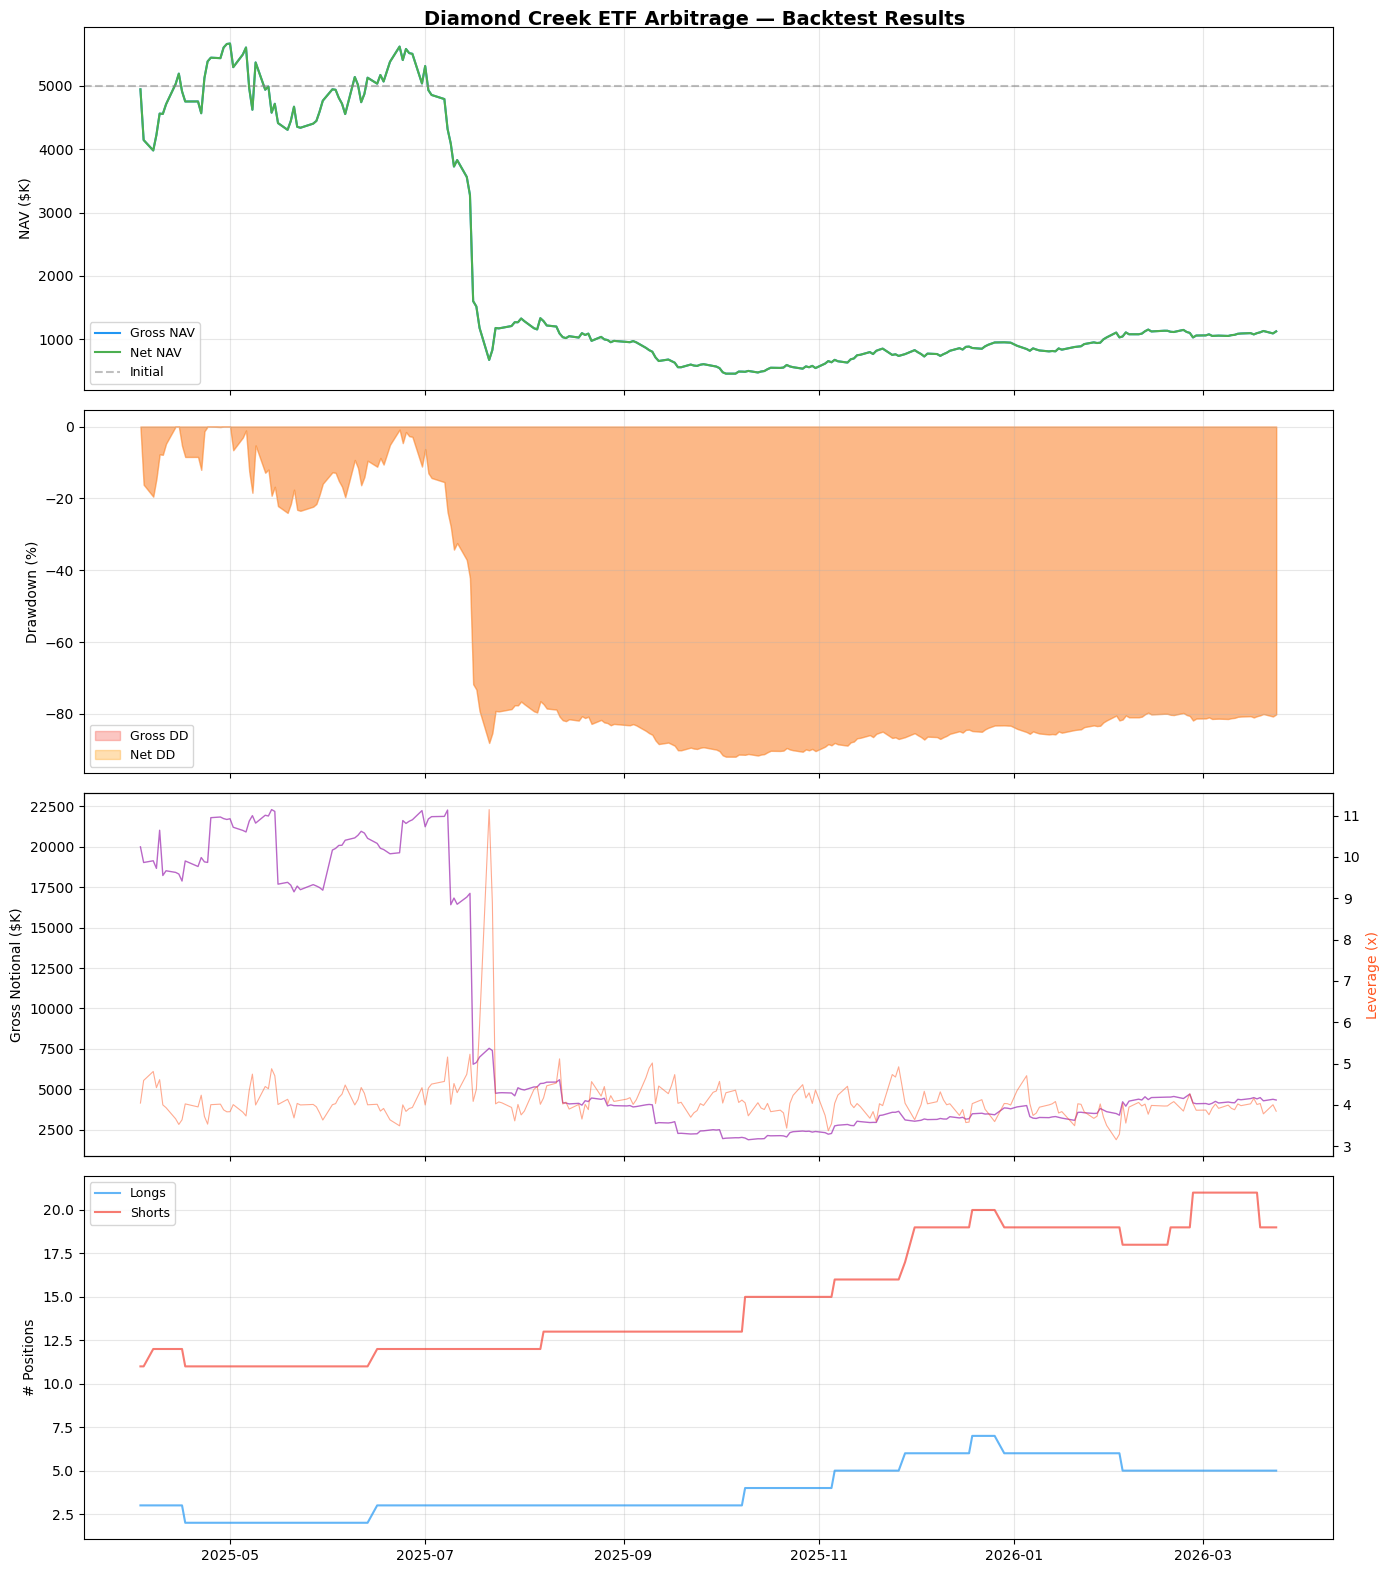

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
fig.suptitle("Diamond Creek ETF Arbitrage — Backtest Results", fontsize=14, fontweight="bold")

ax = axes[0]
ax.plot(BT.index, BT["nav"]/1000, label="Gross NAV", color="#2196F3", lw=1.5)
ax.plot(BT.index, BT["nav_net"]/1000, label="Net NAV", color="#4CAF50", lw=1.5)
ax.axhline(CFG["capital_usd"]/1000, color="gray", ls="--", alpha=0.5, label="Initial")
ax.set_ylabel("NAV ($K)"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
dd_g = (BT["nav"]-BT["nav"].cummax())/BT["nav"].cummax()
dd_n = (BT["nav_net"]-BT["nav_net"].cummax())/BT["nav_net"].cummax()
ax.fill_between(BT.index, dd_g*100, 0, alpha=0.3, color="#F44336", label="Gross DD")
ax.fill_between(BT.index, dd_n*100, 0, alpha=0.3, color="#FF9800", label="Net DD")
ax.set_ylabel("Drawdown (%)"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(BT.index, BT["gross_notional"]/1000, color="#9C27B0", alpha=0.7, lw=1)
ax.set_ylabel("Gross Notional ($K)")
ax2 = ax.twinx(); ax2.plot(BT.index, BT["gross_notional"]/BT["nav"], color="#FF5722", alpha=0.5, lw=0.8)
ax2.set_ylabel("Leverage (x)", color="#FF5722"); ax.grid(True, alpha=0.3)

ax = axes[3]
ax.plot(BT.index, BT["n_longs"], label="Longs", color="#2196F3", alpha=0.7)
ax.plot(BT.index, BT["n_shorts"], label="Shorts", color="#F44336", alpha=0.7)
ax.set_ylabel("# Positions"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout(); plt.show()

## Cell 12 — Monthly Return Tables

In [21]:
def monthly_table(nav):
    mo = nav.resample("ME").last().pct_change().dropna().to_frame("r")
    mo["year"], mo["month"] = mo.index.year, mo.index.month
    piv = mo.pivot(index="year", columns="month", values="r")
    piv.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][:len(piv.columns)]
    yr = nav.resample("YE").last().pct_change().dropna(); yr.index = yr.index.year
    piv["Annual"] = yr
    return piv

print("Monthly Returns (Gross):")
mo_g = monthly_table(BT["nav"])
print(mo_g.map(lambda x: f"{x:+.2%}" if pd.notna(x) else "").to_string())

print("\nMonthly Returns (Net of Fees):")
mo_n = monthly_table(BT["nav_net"])
print(mo_n.map(lambda x: f"{x:+.2%}" if pd.notna(x) else "").to_string())

Monthly Returns (Gross):
         Jan     Feb     Mar      Apr     May      Jun      Jul      Aug     Sep      Oct      Nov   Annual
year                                                                                                       
2025                          -15.80%  +5.69%  -73.59%  -26.55%  -41.46%  -4.13%  +40.12%  +23.50%         
2026  +8.71%  +2.89%  +6.20%                                                                        +18.79%

Monthly Returns (Net of Fees):
         Jan     Feb     Mar      Apr     May      Jun      Jul      Aug     Sep      Oct      Nov   Annual
year                                                                                                       
2025                          -15.80%  +5.69%  -73.59%  -26.55%  -41.46%  -4.13%  +40.12%  +23.50%         
2026  +8.71%  +2.89%  +6.20%                                                                        +18.79%


## Cell 13 — Export Results

In [22]:
out = Path("data/backtest"); out.mkdir(parents=True, exist_ok=True)
BT.to_csv(out/"backtest_nav.csv")
FEE_DF.to_csv(out/"fee_breakdown.csv", index=False)
mo_g.to_csv(out/"monthly_returns_gross.csv")
mo_n.to_csv(out/"monthly_returns_net.csv")
print(f"Saved to {out}/")

Saved to data\backtest/


Fetching AUM for 383 ETFs via yfinance...
  60/383 [14s] — 60 found so far
  100/383 [23s] — 100 found so far
  160/383 [36s] — 152 found so far
  200/383 [45s] — 192 found so far
  260/383 [58s] — 248 found so far
  300/383 [68s] — 285 found so far
  360/383 [81s] — 338 found so far

Done [85.7s] — AUM found for 359/383
AUM data: 359 found, 24 missing

Sample:
      AAPU  AUM=$   154.7M
      AMUU  AUM=$    35.5M
      AMZU  AUM=$   384.7M
      ASMU  AUM=$     4.6M
       AVL  AUM=$   174.0M

         Bucket   Count   % of Universe     Total AUM
-------------------------------------------------------
         < $10M     128          35.7%  $       418M
      $10M–$25M      63          17.5%  $     1,040M
      $25M–$50M      50          13.9%  $     1,791M
     $50M–$100M      30           8.4%  $     2,260M
    $100M–$500M      60          16.7%  $    13,689M
      $500M–$1B      10           2.8%  $     7,208M
          > $1B      18           5.0%  $   136,123M

  < $25M AUM: 191 

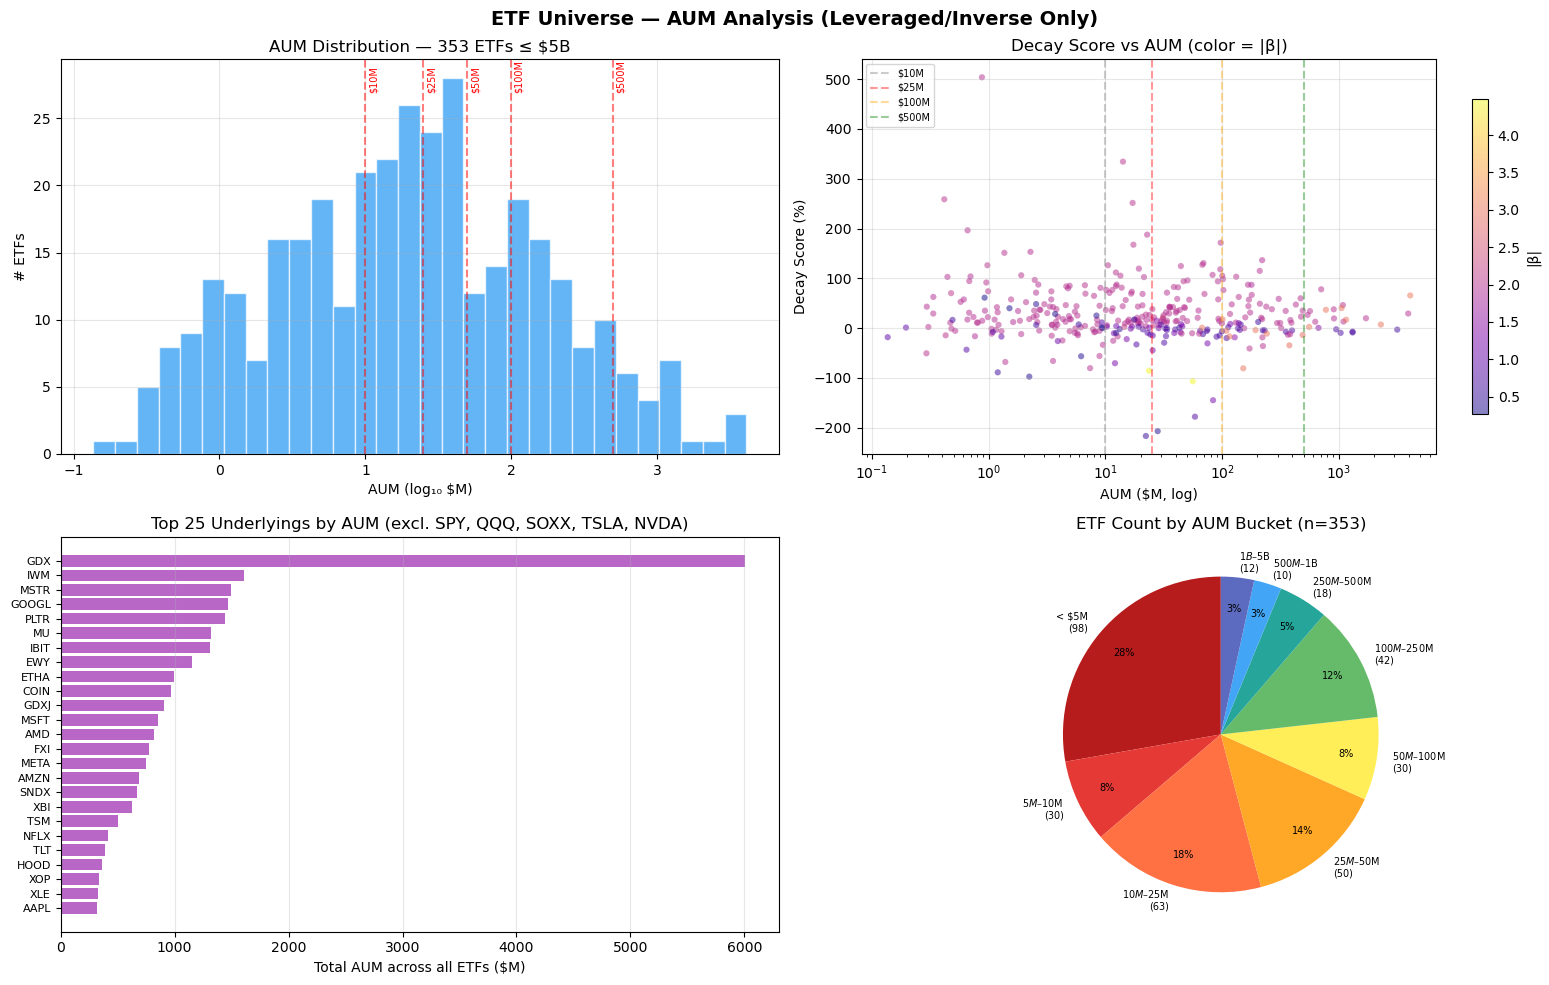


         Bucket   Count       %     Total AUM   Avg Decay
------------------------------------------------------------
          < $5M      98  27.8%  $       197M       35.9%
       $5M–$10M      30   8.5%  $       221M        8.5%
      $10M–$25M      63  17.8%  $     1,040M       35.8%
      $25M–$50M      50  14.2%  $     1,791M       17.3%
     $50M–$100M      30   8.5%  $     2,260M       19.8%
    $100M–$250M      42  11.9%  $     6,829M       26.2%
    $250M–$500M      18   5.1%  $     6,860M       14.3%
      $500M–$1B      10   2.8%  $     7,208M       24.5%
        $1B–$5B      12   3.4%  $    23,245M       17.4%

  CAPACITY RISK: Low-AUM ETFs in active algo universe

  include_for_algo=True with AUM < $25M: 138 ETFs
        COIO →     COIN  AUM=$   0.1M  β= 0.94  decay_score=-18.3%
        MSOO →     MSTR  AUM=$   0.2M  β= 0.97  decay_score=  1.0%
        UECG →      UEC  AUM=$   0.3M  β= 1.97  decay_score= 43.0%
        OKTG →     OKTA  AUM=$   0.3M  β= 1.99  decay_score=

In [1]:
# ── ETF AUM via yfinance (works reliably) ──
import pandas as pd
import numpy as np
import yfinance as yf
import time
import matplotlib.pyplot as plt

screened = pd.read_csv("../data/etf_screened_today.csv")
etf_list = screened["ETF"].str.strip().str.upper().str.replace(".", "-").tolist()
print(f"Fetching AUM for {len(etf_list)} ETFs via yfinance...")

aum_map = {}
t0 = time.monotonic()

# Batch in chunks of 20 to avoid rate limits
for i in range(0, len(etf_list), 20):
    batch = etf_list[i:i+20]
    for tick in batch:
        try:
            info = yf.Ticker(tick).info
            aum = info.get("totalAssets") or info.get("netAssets")
            if aum and aum > 0:
                aum_map[tick] = aum
        except Exception:
            pass
    elapsed = time.monotonic() - t0
    done = min(i + 20, len(etf_list))
    if done % 50 < 20:
        print(f"  {done}/{len(etf_list)} [{elapsed:.0f}s] — {len(aum_map)} found so far")

print(f"\nDone [{time.monotonic()-t0:.1f}s] — AUM found for {len(aum_map)}/{len(etf_list)}")

# Build DataFrame
screened["AUM"] = screened["ETF"].str.strip().str.upper().str.replace(".", "-").map(aum_map)
screened["AUM_M"] = screened["AUM"] / 1e6
has_aum = screened["AUM"].notna()
print(f"AUM data: {has_aum.sum()} found, {(~has_aum).sum()} missing")

# Quick sanity check — print a few
print("\nSample:")
for _, r in screened[has_aum].head(5).iterrows():
    print(f"  {r['ETF']:>8s}  AUM=${r['AUM_M']:>8,.1f}M")
# ═══════════════════════════════════════════════════════════════
# 1. AUM bucket breakdown
# ═══════════════════════════════════════════════════════════════
df = screened[has_aum].copy()

buckets = [
    ("< $10M",    df["AUM_M"] < 10),
    ("$10M–$25M", (df["AUM_M"] >= 10) & (df["AUM_M"] < 25)),
    ("$25M–$50M", (df["AUM_M"] >= 25) & (df["AUM_M"] < 50)),
    ("$50M–$100M",(df["AUM_M"] >= 50) & (df["AUM_M"] < 100)),
    ("$100M–$500M",(df["AUM_M"] >= 100) & (df["AUM_M"] < 500)),
    ("$500M–$1B", (df["AUM_M"] >= 500) & (df["AUM_M"] < 1000)),
    ("> $1B",     df["AUM_M"] >= 1000),
]

print(f"\n{'Bucket':>15s}  {'Count':>6s}  {'% of Universe':>14s}  {'Total AUM':>12s}")
print("-" * 55)
for label, mask in buckets:
    n = mask.sum()
    pct = n / len(df)
    total = df.loc[mask, "AUM_M"].sum()
    print(f"{label:>15s}  {n:>6d}  {pct:>13.1%}  ${total:>10,.0f}M")

# Cumulative thresholds
for thresh in [25, 50, 100]:
    n_below = (df["AUM_M"] < thresh).sum()
    n_above = (df["AUM_M"] >= thresh).sum()
    print(f"\n  < ${thresh}M AUM: {n_below} ETFs ({n_below/len(df):.1%})"
          f"  |  ≥ ${thresh}M AUM: {n_above} ETFs ({n_above/len(df):.1%})")

# ═══════════════════════════════════════════════════════════════
# 2. AUM by underlying
# ═══════════════════════════════════════════════════════════════
und_aum = df.groupby("Underlying").agg(
    n_etfs=("ETF", "count"),
    total_aum_m=("AUM_M", "sum"),
    median_aum_m=("AUM_M", "median"),
    max_aum_m=("AUM_M", "max"),
    min_aum_m=("AUM_M", "min"),
    avg_beta=("Beta", "mean"),
).sort_values("total_aum_m", ascending=False)

print(f"\n{'='*80}")
print(f"  AUM by Underlying (top 30)")
print(f"{'='*80}")
print(f"{'Underlying':>12s}  {'# ETFs':>7s}  {'Total AUM':>12s}  {'Median':>10s}  "
      f"{'Largest':>10s}  {'Smallest':>10s}  {'Avg β':>6s}")
print("-" * 80)
for und, row in und_aum.head(30).iterrows():
    print(f"{und:>12s}  {int(row['n_etfs']):>7d}  ${row['total_aum_m']:>10,.0f}M  "
          f"${row['median_aum_m']:>8,.0f}M  ${row['max_aum_m']:>8,.0f}M  "
          f"${row['min_aum_m']:>8,.0f}M  {row['avg_beta']:>5.1f}")

# ═══════════════════════════════════════════════════════════════
# 3. Visualizations (excluding index ETFs, granular pie)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("ETF Universe — AUM Analysis (Leveraged/Inverse Only)", fontsize=14, fontweight="bold")

# Filter out massive index/covered-call ETFs that aren't really "our" universe
AUM_CAP = 5000  # exclude ETFs > $5B (JEPI, JEPQ, QYLD, SQQQ, etc.)
df_lev = df[df["AUM_M"] <= AUM_CAP].copy()
print(f"Filtered to AUM ≤ ${AUM_CAP/1000:.0f}B: {len(df_lev)}/{len(df)} ETFs "
      f"(dropped {len(df)-len(df_lev)} mega-cap)")

# 3a. Histogram of log AUM (filtered)
ax = axes[0, 0]
log_aum = np.log10(df_lev["AUM_M"].clip(lower=0.1))
ax.hist(log_aum, bins=30, color="#2196F3", alpha=0.7, edgecolor="white")
for thresh in [10, 25, 50, 100, 500]:
    ax.axvline(np.log10(thresh), color="red", ls="--", alpha=0.5)
    ax.text(np.log10(thresh)+0.02, ax.get_ylim()[1]*0.92, f"${thresh}M",
            color="red", fontsize=7, ha="left", rotation=90)
ax.set_xlabel("AUM (log₁₀ $M)")
ax.set_ylabel("# ETFs")
ax.set_title(f"AUM Distribution — {len(df_lev)} ETFs ≤ ${AUM_CAP/1000:.0f}B")
ax.grid(True, alpha=0.3)

# 3b. AUM vs decay score (filtered)
ax = axes[0, 1]
valid = df_lev["decay_score"].notna() & df_lev["AUM_M"].notna()
sc = ax.scatter(df_lev.loc[valid, "AUM_M"], df_lev.loc[valid, "decay_score"]*100,
                alpha=0.5, s=20, c=df_lev.loc[valid, "Beta"].abs(), cmap="plasma", 
                edgecolors="none")
ax.set_xscale("log")
ax.set_xlabel("AUM ($M, log)")
ax.set_ylabel("Decay Score (%)")
ax.set_title("Decay Score vs AUM (color = |β|)")
for thresh, col in [(10, "gray"), (25, "red"), (100, "orange"), (500, "green")]:
    ax.axvline(thresh, color=col, ls="--", alpha=0.4, label=f"${thresh}M")
ax.legend(fontsize=7, loc="upper left")
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label="|β|", shrink=0.8)

# 3c. Top 25 underlyings by total AUM (EXCLUDING top 5 mega-caps)
ax = axes[1, 0]
und_aum_trimmed = und_aum.copy()
# Drop the index underlyings that skew the chart
mega = und_aum_trimmed.head(5).index.tolist()
und_aum_trimmed = und_aum_trimmed.drop(mega, errors="ignore")
top25 = und_aum_trimmed.head(25)
ax.barh(range(len(top25)), top25["total_aum_m"], color="#9C27B0", alpha=0.7)
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25.index, fontsize=8)
ax.set_xlabel("Total AUM across all ETFs ($M)")
ax.set_title(f"Top 25 Underlyings by AUM (excl. {', '.join(mega)})")
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")

# 3d. Granular pie chart
ax = axes[1, 1]
pie_buckets = [
    ("< $5M",       df_lev["AUM_M"] < 5),
    ("$5M–$10M",    (df_lev["AUM_M"] >= 5)   & (df_lev["AUM_M"] < 10)),
    ("$10M–$25M",   (df_lev["AUM_M"] >= 10)  & (df_lev["AUM_M"] < 25)),
    ("$25M–$50M",   (df_lev["AUM_M"] >= 25)  & (df_lev["AUM_M"] < 50)),
    ("$50M–$100M",  (df_lev["AUM_M"] >= 50)  & (df_lev["AUM_M"] < 100)),
    ("$100M–$250M", (df_lev["AUM_M"] >= 100) & (df_lev["AUM_M"] < 250)),
    ("$250M–$500M", (df_lev["AUM_M"] >= 250) & (df_lev["AUM_M"] < 500)),
    ("$500M–$1B",   (df_lev["AUM_M"] >= 500) & (df_lev["AUM_M"] < 1000)),
    ("$1B–$5B",     (df_lev["AUM_M"] >= 1000)),
]
colors = ["#b71c1c","#e53935","#ff7043","#ffa726","#ffee58",
          "#66bb6a","#26a69a","#42a5f5","#5c6bc0"]
counts = [m.sum() for _, m in pie_buckets]
nonzero = [(l, c, col) for l, c, col in zip(
    [l for l,_ in pie_buckets], counts, colors) if c > 0]

wedges, texts, autotexts = ax.pie(
    [c for _, c, _ in nonzero],
    labels=[f"{l}\n({c})" for l, c, _ in nonzero],
    colors=[col for _, _, col in nonzero],
    autopct="%1.0f%%", startangle=90, pctdistance=0.8,
    textprops={"fontsize": 7})
for t in autotexts:
    t.set_fontsize(7)
ax.set_title(f"ETF Count by AUM Bucket (n={len(df_lev)})")

plt.tight_layout()
plt.show()

# Print the granular breakdown too
print(f"\n{'Bucket':>15s}  {'Count':>6s}  {'%':>6s}  {'Total AUM':>12s}  {'Avg Decay':>10s}")
print("-" * 60)
for (label, mask), _ in zip(pie_buckets, range(len(pie_buckets))):
    n = mask.sum()
    if n == 0: continue
    total = df_lev.loc[mask, "AUM_M"].sum()
    avg_ds = df_lev.loc[mask, "decay_score"].mean()
    avg_str = f"{avg_ds*100:.1f}%" if pd.notna(avg_ds) else "N/A"
    print(f"{label:>15s}  {n:>6d}  {n/len(df_lev):>5.1%}  ${total:>10,.0f}M  {avg_str:>10s}")

# ═══════════════════════════════════════════════════════════════
# 4. Flag low-AUM names that the strategy is likely trading
# ═══════════════════════════════════════════════════════════════
algo_etfs = df[df["include_for_algo"] == True].copy()
print(f"\n{'='*70}")
print(f"  CAPACITY RISK: Low-AUM ETFs in active algo universe")
print(f"{'='*70}")
for thresh in [25, 50]:
    low = algo_etfs[algo_etfs["AUM_M"] < thresh].sort_values("AUM_M")
    print(f"\n  include_for_algo=True with AUM < ${thresh}M: {len(low)} ETFs")
    if not low.empty:
        for _, r in low.head(15).iterrows():
            ds = r.get("decay_score", np.nan)
            print(f"    {r['ETF']:>8s} → {r['Underlying']:>8s}  "
                  f"AUM=${r['AUM_M']:>6.1f}M  β={r['Beta']:>5.2f}  "
                  f"decay_score={ds*100:>5.1f}%" if pd.notna(ds) else
                  f"    {r['ETF']:>8s} → {r['Underlying']:>8s}  "
                  f"AUM=${r['AUM_M']:>6.1f}M  β={r['Beta']:>5.2f}  decay_score=  N/A")
        if len(low) > 15:
            print(f"    ... and {len(low)-15} more")

In [9]:
# ── Core leveraged underlyings with sub-$10M AUM ETFs ──
import pandas as pd
import numpy as np

trades = pd.read_csv("../data/proposed_trades.csv")
trades["gross_usd"] = trades["long_usd"].abs() + trades["short_usd"].abs()
core = trades[(trades["sleeve"] == "core_leveraged") & (trades["gross_usd"] > 0)].copy()
core["AUM"] = core["ETF"].str.strip().str.upper().str.replace(".", "-").map(aum_map)
core["AUM_M"] = core["AUM"] / 1e6

has_aum = core["AUM"].notna()
print(f"Core pairs with AUM data: {has_aum.sum()}/{len(core)}")

# Flag underlyings where ANY ETF has < $10M AUM
und_groups = core[has_aum].groupby("Underlying").agg(
    n_etfs=("ETF", "count"),
    min_aum_M=("AUM_M", "min"),
    max_aum_M=("AUM_M", "max"),
    median_aum_M=("AUM_M", "median"),
    total_gross=("gross_usd", "sum"),
    etfs=("ETF", list),
    aums=("AUM_M", list),
)

has_sub10 = und_groups[und_groups["min_aum_M"] < 10]
all_sub5 = und_groups[und_groups["max_aum_M"] < 5]  # ALL etfs under $10M

print(f"\nTotal core underlyings with AUM: {len(und_groups)}")
print(f"Underlyings where ALL ETFs < $5M: {len(all_sub5)}")

for thresh in [5, 10, 25, 50]:
    any_below = (und_groups["min_aum_M"] < thresh).sum()
    all_below = (und_groups["max_aum_M"] < thresh).sum()
    print(f"\n  < ${thresh}M:  {any_below} underlyings (any ETF)  |  "
          f"{all_below} underlyings (all ETFs)")

print(f"\n{'='*95}")
print(f"  Underlyings where ALL ETFs have < $5M AUM ({len(all_sub5)})")
print(f"{'='*95}")
print(f"{'Underlying':>12s}  {'#ETFs':>6s}  {'ETFs':>40s}  {'AUMs ($M)':>30s}")
print("-" * 95)
for und, row in all_sub5.sort_values("total_gross", ascending=False).iterrows():
    etf_aum_strs = [f"{e}=${a:.1f}M" for e, a in zip(row["etfs"], row["aums"])]
    print(f"{und:>12s}  {row['n_etfs']:>6d}  {', '.join(row['etfs']):>40s}  "
          f"{', '.join(f'${a:.1f}M' for a in row['aums']):>30s}  "
          f"${row['total_gross']:>8,.0f}")



Core pairs with AUM data: 186/196

Total core underlyings with AUM: 138
Underlyings where ALL ETFs < $5M: 50

  < $5M:  61 underlyings (any ETF)  |  50 underlyings (all ETFs)

  < $10M:  71 underlyings (any ETF)  |  60 underlyings (all ETFs)

  < $25M:  94 underlyings (any ETF)  |  78 underlyings (all ETFs)

  < $50M:  113 underlyings (any ETF)  |  96 underlyings (all ETFs)

  Underlyings where ALL ETFs have < $5M AUM (50)
  Underlying   #ETFs                                      ETFs                       AUMs ($M)
-----------------------------------------------------------------------------------------------
        CRML       1                                      CRMU                           $0.7M  $  23,321
        PLUG       1                                      PLUL                           $0.7M  $  15,574
        BITF       1                                      BTFL                           $1.9M  $  15,559
        EOSE       1                                      EOSU  

  AUM FILTER: Kill ETFs with < $5M AUM
  Before filter:     186 pairs  |  138 underlyings
  Killed (< $5M):     64 pairs  |  61 underlyings
  Surviving:         122 pairs  |  88 underlyings
  No AUM data:        10 pairs  (excluded from both)

  Underlyings completely lost: 50
           AAL: AALG($1.2M)  avg_decay=6.6%
          ABNB: ABNG($0.5M)  avg_decay=-5.5%
           APH: APHU($0.5M)  avg_decay=-1.0%
          BITF: BTFL($1.9M)  avg_decay=106.1%
          BLSH: BLSG($1.2M)  avg_decay=42.0%
          CIFR: CIFG($2.5M)  avg_decay=96.8%
           CMG: CMGG($0.9M)  avg_decay=14.7%
           CNC: CNCG($0.5M)  avg_decay=10.8%
          CORZ: COZX($3.4M)  avg_decay=73.8%
          CRML: CRMU($0.7M)  avg_decay=196.4%
          DDOG: DOGD($2.6M)  avg_decay=12.0%
           DNN: DNNG($0.7M)  avg_decay=17.1%
          EOSE: EOSU($2.3M)  avg_decay=153.2%
          ETOR: ETRL($1.2M)  avg_decay=31.8%
             F: FRDU($3.7M)  avg_decay=0.9%
           FCX: FCXG($0.8M)  avg_decay=11.0%
 

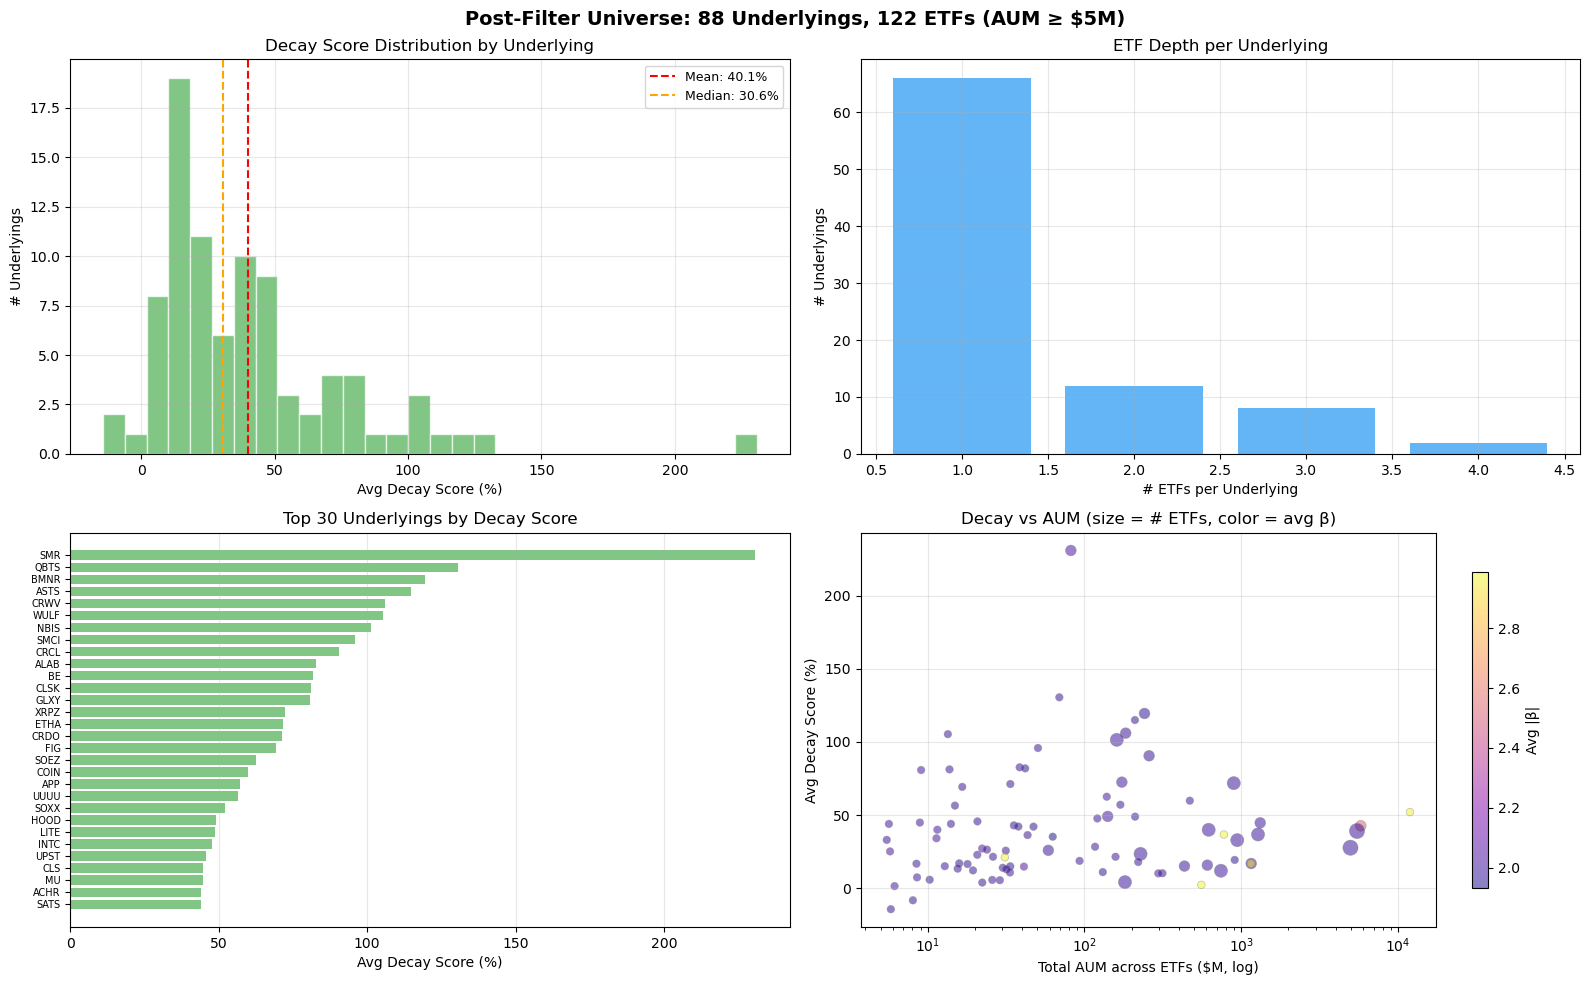

In [23]:
# ── Post-$5M AUM filter: diversification & decay by underlying ──
import pandas as pd
import numpy as np

trades = pd.read_csv("../data/proposed_trades.csv")
trades["gross_usd"] = trades["long_usd"].abs() + trades["short_usd"].abs()
core = trades[(trades["sleeve"] == "core_leveraged") & (trades["gross_usd"] > 0)].copy()
core["AUM"] = core["ETF"].str.strip().str.upper().str.replace(".", "-").map(aum_map)
core["AUM_M"] = core["AUM"] / 1e6
core["decay_score"] = pd.to_numeric(core.get("decay_score"), errors="coerce")
core["blended_gross_decay"] = pd.to_numeric(core.get("blended_gross_decay"), errors="coerce")
core["borrow_current"] = pd.to_numeric(core.get("borrow_current"), errors="coerce")
core["Beta"] = pd.to_numeric(core["Beta"], errors="coerce")

# ── Before vs after filter ──
has_aum = core["AUM"].notna()
pre = core[has_aum]
post = core[has_aum & (core["AUM_M"] >= 5)].copy()
killed = core[has_aum & (core["AUM_M"] < 5)]
no_aum = core[~has_aum]

print(f"{'='*60}")
print(f"  AUM FILTER: Kill ETFs with < $5M AUM")
print(f"{'='*60}")
print(f"  Before filter:    {len(pre):>4d} pairs  |  {pre['Underlying'].nunique()} underlyings")
print(f"  Killed (< $5M):   {len(killed):>4d} pairs  |  {killed['Underlying'].nunique()} underlyings")
print(f"  Surviving:        {len(post):>4d} pairs  |  {post['Underlying'].nunique()} underlyings")
print(f"  No AUM data:      {len(no_aum):>4d} pairs  (excluded from both)")

# How many underlyings lost ALL their ETFs?
pre_unds = set(pre["Underlying"].unique())
post_unds = set(post["Underlying"].unique())
lost_unds = pre_unds - post_unds
print(f"\n  Underlyings completely lost: {len(lost_unds)}")
if lost_unds:
    for u in sorted(lost_unds):
        etfs = killed[killed["Underlying"] == u]["ETF"].tolist()
        aums = killed[killed["Underlying"] == u]["AUM_M"].tolist()
        ds = killed[killed["Underlying"] == u]["decay_score"].mean()
        detail = ", ".join(f"{e}(${a:.1f}M)" for e, a in zip(etfs, aums))
        print(f"    {u:>10s}: {detail}  avg_decay={ds*100:.1f}%" if pd.notna(ds) else
              f"    {u:>10s}: {detail}")

# ═══════════════════════════════════════════════════════════════
# Group surviving ETFs by underlying
# ═══════════════════════════════════════════════════════════════
und = post.groupby("Underlying").agg(
    n_etfs=("ETF", "count"),
    etfs=("ETF", list),
    total_aum_M=("AUM_M", "sum"),
    min_aum_M=("AUM_M", "min"),
    max_aum_M=("AUM_M", "max"),
    avg_beta=("Beta", "mean"),
    avg_blended_decay=("blended_gross_decay", "mean"),
    avg_borrow=("borrow_current", "mean"),
    avg_decay_score=("decay_score", "mean"),
    best_decay_score=("decay_score", "max"),
    total_gross=("gross_usd", "sum"),
).sort_values("avg_decay_score", ascending=False)

print(f"\n{'='*120}")
print(f"  SURVIVING UNIVERSE: {len(und)} underlyings, {len(post)} ETFs (after $5M AUM filter)")
print(f"{'='*120}")
print(f"{'Underlying':>10s}  {'#ETF':>5s}  {'ETFs':>35s}  {'TotAUM':>8s}  "
      f"{'AvgBeta':>8s}  {'Decay%':>7s}  {'Borrow%':>8s}  {'Score%':>7s}  {'BestScr%':>9s}")
print("-" * 120)
for u, r in und.iterrows():
    etf_str = ", ".join(r["etfs"][:4])
    if len(r["etfs"]) > 4:
        etf_str += f" +{len(r['etfs'])-4}"
    ad = r["avg_blended_decay"]
    ab = r["avg_borrow"]
    ds = r["avg_decay_score"]
    bs = r["best_decay_score"]
    print(f"{u:>10s}  {int(r['n_etfs']):>5d}  {etf_str:>35s}  "
          f"${r['total_aum_M']:>6,.0f}M  "
          f"{r['avg_beta']:>7.2f}  "
          f"{ad*100:>5.1f}%  " if pd.notna(ad) else f"{'':>7s}  "
          f"{ab*100:>6.1f}%  " if pd.notna(ab) else f"{'':>8s}  "
          f"{ds*100:>5.1f}%  " if pd.notna(ds) else f"{'':>7s}  "
          f"{bs*100:>7.1f}%" if pd.notna(bs) else f"{'':>9s}")

# ═══════════════════════════════════════════════════════════════
# Diversification stats
# ═══════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  DIVERSIFICATION SUMMARY")
print(f"{'='*60}")

# ETF count distribution
etf_counts = und["n_etfs"]
print(f"\n  ETFs per underlying:")
for n in sorted(etf_counts.unique()):
    c = (etf_counts == n).sum()
    print(f"    {n} ETF{'s' if n > 1 else ' '}: {c:>3d} underlyings ({c/len(und):.0%})")

# Decay score distribution
valid_ds = und["avg_decay_score"].dropna()
print(f"\n  Decay score distribution (avg per underlying):")
for lo, hi, label in [(0.20, 9, "> 20%"), (0.10, 0.20, "10-20%"),
                       (0.05, 0.10, "5-10%"), (0.02, 0.05, "2-5%"),
                       (0, 0.02, "0-2%"), (-9, 0, "< 0% (negative)")]:
    n = ((valid_ds >= lo) & (valid_ds < hi)).sum()
    print(f"    {label:>15s}: {n:>3d} underlyings")

# If we equal-weight underlyings, what's the expected portfolio decay?
ew_decay = valid_ds.mean()
ew_decay_med = valid_ds.median()
print(f"\n  Equal-weight underlying decay:")
print(f"    Mean:   {ew_decay*100:.2f}%")
print(f"    Median: {ew_decay_med*100:.2f}%")

# At $6M / 4x = $24M gross, what's per-underlying if equal-weighted?
gross_target = 24_000_000
per_und = gross_target / len(und)
print(f"\n  At $24M gross across {len(und)} underlyings:")
print(f"    Per-underlying gross: ${per_und:,.0f}")
print(f"    Per-underlying long:  ~${per_und * 0.67:,.0f}")
print(f"    Per-underlying short: ~${per_und * 0.33:,.0f}")

# ═══════════════════════════════════════════════════════════════
# Visualizations
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"Post-Filter Universe: {len(und)} Underlyings, {len(post)} ETFs (AUM ≥ $5M)",
             fontsize=14, fontweight="bold")

# Decay score histogram by underlying
ax = axes[0, 0]
ax.hist(valid_ds * 100, bins=30, color="#4CAF50", alpha=0.7, edgecolor="white")
ax.axvline(ew_decay*100, color="red", ls="--", label=f"Mean: {ew_decay*100:.1f}%")
ax.axvline(ew_decay_med*100, color="orange", ls="--", label=f"Median: {ew_decay_med*100:.1f}%")
ax.set_xlabel("Avg Decay Score (%)")
ax.set_ylabel("# Underlyings")
ax.set_title("Decay Score Distribution by Underlying")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ETFs per underlying bar
ax = axes[0, 1]
counts = etf_counts.value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#2196F3", alpha=0.7)
ax.set_xlabel("# ETFs per Underlying")
ax.set_ylabel("# Underlyings")
ax.set_title("ETF Depth per Underlying")
ax.grid(True, alpha=0.3)

# Top 30 underlyings by decay score
ax = axes[1, 0]
top30 = und.head(30)
colors = ["#4CAF50" if ds > 0 else "#F44336" for ds in top30["avg_decay_score"].fillna(0)]
ax.barh(range(len(top30)), top30["avg_decay_score"].fillna(0)*100, color=colors, alpha=0.7)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index, fontsize=7)
ax.set_xlabel("Avg Decay Score (%)")
ax.set_title("Top 30 Underlyings by Decay Score")
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")

# Decay score vs total AUM per underlying
ax = axes[1, 1]
valid_plot = und["avg_decay_score"].notna() & (und["total_aum_M"] > 0)
sc = ax.scatter(und.loc[valid_plot, "total_aum_M"],
                und.loc[valid_plot, "avg_decay_score"]*100,
                s=und.loc[valid_plot, "n_etfs"]*30,
                alpha=0.5, c=und.loc[valid_plot, "avg_beta"],
                cmap="plasma", edgecolors="gray", linewidths=0.5)
ax.set_xscale("log")
ax.set_xlabel("Total AUM across ETFs ($M, log)")
ax.set_ylabel("Avg Decay Score (%)")
ax.set_title("Decay vs AUM (size = # ETFs, color = avg β)")
plt.colorbar(sc, ax=ax, label="Avg |β|", shrink=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
!pip install openpyxl -q

In [30]:
# ── Regenerate Excel with AUM data + $5M filter ──
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter
from pathlib import Path

trades = pd.read_csv("../data/proposed_trades.csv")
trades["gross_usd"] = trades["long_usd"].abs() + trades["short_usd"].abs()
core = trades[(trades["sleeve"] == "core_leveraged") & (trades["gross_usd"] > 0)].copy()
core["ETF_clean"] = core["ETF"].str.strip().str.upper().str.replace(".", "-")
core["AUM"] = core["ETF_clean"].map(aum_map)
core["AUM_M"] = core["AUM"] / 1e6
core["Beta"] = pd.to_numeric(core["Beta"], errors="coerce")
core["decay_score"] = pd.to_numeric(core.get("decay_score"), errors="coerce")
core["blended_gross_decay"] = pd.to_numeric(core.get("blended_gross_decay"), errors="coerce")
core["borrow_current"] = pd.to_numeric(core.get("borrow_current"), errors="coerce")

# Sanity check AUM mapping
print(f"AUM mapped: {core['AUM'].notna().sum()}/{len(core)}")
print(f"Sample AUM values:")
for _, r in core[core["AUM"].notna()].head(5).iterrows():
    print(f"  {r['ETF_clean']:>8s}  AUM=${r['AUM_M']:>8.1f}M")

# Apply $5M AUM filter
has_aum = core["AUM"].notna()
post = core[has_aum & (core["AUM_M"] >= 5)].copy()
print(f"\nAfter $5M AUM filter: {len(post)} ETFs across {post['Underlying'].nunique()} underlyings")

GROSS_TARGET = 40_000_000
max_etfs = post.groupby("Underlying").size().max()

# ── Build workbook ──
wb = Workbook()
hf = Font(name="Arial", bold=True, size=10, color="FFFFFF")
hfill = PatternFill("solid", fgColor="2F5496")
dfont = Font(name="Arial", size=9)
pct = '0.0%'; money = '$#,##0'; aum_fmt = '#,##0.0'

# ═══════════════════════════════════════════════════════════════
# Sheet 1: Universe Map
# ═══════════════════════════════════════════════════════════════
ws = wb.active; ws.title = "Universe Map"

fixed = ["Underlying", "# ETFs", "Total AUM ($M)", "Avg |β|",
         "Avg Blended Decay", "Avg Borrow", "Avg Decay Score"]
per_etf = ["ETF", "AUM ($M)", "|β|", "Decay Score", "Borrow"]

headers = fixed + [f"{c} {i+1}" for i in range(max_etfs) for c in per_etf]
for ci, h in enumerate(headers, 1):
    c = ws.cell(row=1, column=ci, value=h)
    c.font = hf; c.fill = hfill; c.alignment = Alignment(horizontal="center", wrap_text=True)

ws.column_dimensions["A"].width = 12
ws.column_dimensions["B"].width = 7
ws.column_dimensions["C"].width = 13
ws.column_dimensions["D"].width = 8
ws.column_dimensions["E"].width = 15
ws.column_dimensions["F"].width = 10
ws.column_dimensions["G"].width = 14
for i in range(max_etfs):
    base = len(fixed) + i * len(per_etf)
    for j, w in enumerate([8, 12, 6, 11, 9]):
        ws.column_dimensions[get_column_letter(base + j + 1)].width = w
ws.freeze_panes = "A2"

# Group and sort — build per-ETF dicts with explicit AUM
und_data = []
for und_name, group in post.groupby("Underlying"):
    group = group.sort_values("AUM_M", ascending=False)
    
    etf_records = []
    for _, row in group.iterrows():
        etf_records.append({
            "ETF": row["ETF_clean"],
            "AUM_M": float(row["AUM_M"]) if pd.notna(row["AUM_M"]) else None,
            "Beta": float(row["Beta"]) if pd.notna(row["Beta"]) else None,
            "decay_score": float(row["decay_score"]) if pd.notna(row["decay_score"]) else None,
            "borrow_current": float(row["borrow_current"]) if pd.notna(row["borrow_current"]) else None,
        })
    
    und_data.append({
        "underlying": und_name,
        "n_etfs": len(group),
        "total_aum": group["AUM_M"].sum(),
        "avg_beta": group["Beta"].mean(),
        "avg_decay": group["blended_gross_decay"].mean(),
        "avg_borrow": group["borrow_current"].mean(),
        "avg_score": group["decay_score"].mean(),
        "etfs": etf_records,
    })

und_data.sort(key=lambda x: x["avg_score"] if pd.notna(x["avg_score"]) else -999, reverse=True)

# Write rows
for ri, ud in enumerate(und_data, 2):
    ws.cell(row=ri, column=1, value=ud["underlying"]).font = Font(name="Arial", bold=True, size=9)
    ws.cell(row=ri, column=2, value=ud["n_etfs"]).font = dfont
    c = ws.cell(row=ri, column=3, value=ud["total_aum"]); c.font = dfont; c.number_format = aum_fmt
    c = ws.cell(row=ri, column=4, value=ud["avg_beta"]); c.font = dfont; c.number_format = '0.00'
    c = ws.cell(row=ri, column=5, value=ud["avg_decay"]); c.font = dfont; c.number_format = pct
    c = ws.cell(row=ri, column=6, value=ud["avg_borrow"]); c.font = dfont; c.number_format = pct
    c = ws.cell(row=ri, column=7, value=ud["avg_score"]); c.font = dfont; c.number_format = pct

    for i, etf in enumerate(ud["etfs"]):
        base = len(fixed) + i * len(per_etf)
        
        # ETF ticker
        ws.cell(row=ri, column=base+1, value=etf["ETF"]).font = Font(
            name="Arial", size=9, bold=True, color="2F5496")
        
        # AUM — the key column
        aum_val = etf["AUM_M"]
        c = ws.cell(row=ri, column=base+2, value=aum_val if aum_val is not None else "N/A")
        c.font = dfont
        if aum_val is not None:
            c.number_format = aum_fmt
        
        # Beta
        c = ws.cell(row=ri, column=base+3, value=etf["Beta"]); c.font = dfont; c.number_format = '0.00'
        # Decay score
        c = ws.cell(row=ri, column=base+4, value=etf["decay_score"]); c.font = dfont; c.number_format = pct
        # Borrow
        c = ws.cell(row=ri, column=base+5, value=etf["borrow_current"]); c.font = dfont; c.number_format = pct

    # Alternating rows
    if ri % 2 == 0:
        for col in range(1, len(headers)+1):
            ws.cell(row=ri, column=col).fill = PatternFill("solid", fgColor="F2F2F2")

# ═══════════════════════════════════════════════════════════════
# Sheet 2: Sizing at $40M Gross
# ═══════════════════════════════════════════════════════════════
ws2 = wb.create_sheet("Sizing $40M Gross")
n_unds = len(und_data)

sizing_h = ["Underlying", "# ETFs", "Total AUM ($M)", "Avg |β|", "Hedge Ratio",
            "Avg Decay Score", "Avg Borrow",
            "Gross Alloc", "Long Alloc", "Short Alloc",
            "Exp Annual Decay ($)", "Exp Annual Borrow ($)", "Exp Net P&L ($)"]
for ci, h in enumerate(sizing_h, 1):
    c = ws2.cell(row=1, column=ci, value=h)
    c.font = hf; c.fill = hfill; c.alignment = Alignment(horizontal="center", wrap_text=True)
for i, w in enumerate([12,7,13,8,9,14,10,13,13,13,16,16,16]):
    ws2.column_dimensions[get_column_letter(i+1)].width = w
ws2.freeze_panes = "A2"

for ri, ud in enumerate(und_data, 2):
    ab = ud["avg_beta"] if pd.notna(ud["avg_beta"]) else 2.0
    hr = 1.0 / max(abs(ab), 0.1)
    gross = GROSS_TARGET / n_unds
    long_usd = gross / (1 + hr)
    short_usd = gross - long_usd
    sc = ud["avg_score"] if pd.notna(ud["avg_score"]) else 0
    br = ud["avg_borrow"] if pd.notna(ud["avg_borrow"]) else 0
    decay_dollar = short_usd * sc
    borrow_dollar = short_usd * br
    net = decay_dollar - borrow_dollar

    vals = [ud["underlying"], ud["n_etfs"], ud["total_aum"], ab, hr,
            ud["avg_score"], ud["avg_borrow"],
            gross, long_usd, short_usd, decay_dollar, borrow_dollar, net]
    fmts = [None, None, aum_fmt, '0.00', '0.00', pct, pct,
            money, money, money, money, money, money]
    for ci, (val, fmt) in enumerate(zip(vals, fmts), 1):
        c = ws2.cell(row=ri, column=ci, value=val)
        c.font = dfont
        if fmt: c.number_format = fmt
    if ri % 2 == 0:
        for col in range(1, len(sizing_h)+1):
            ws2.cell(row=ri, column=col).fill = PatternFill("solid", fgColor="F2F2F2")

# Totals
tr = ri + 1
ws2.cell(row=tr, column=1, value="TOTAL").font = Font(name="Arial", bold=True, size=10)
for ci in [2, 8, 9, 10, 11, 12, 13]:
    cl = get_column_letter(ci)
    c = ws2.cell(row=tr, column=ci, value=f"=SUM({cl}2:{cl}{tr-1})")
    c.font = Font(name="Arial", bold=True, size=10)
    if ci >= 8: c.number_format = money

# Summary
ws2.cell(row=tr+2, column=1, value="PORTFOLIO SUMMARY").font = Font(name="Arial", bold=True, size=11)
for i, (lbl, val, fmt) in enumerate([
    ("Gross Target", GROSS_TARGET, money),
    ("# Underlyings", n_unds, '#,##0'),
    ("Per-Underlying Gross", GROSS_TARGET / n_unds, money),
    ("Per-Underlying Long", (GROSS_TARGET/n_unds)*0.67, money),
    ("Per-Underlying Short", (GROSS_TARGET/n_unds)*0.33, money),
]):
    r = tr + 3 + i
    ws2.cell(row=r, column=1, value=lbl).font = Font(name="Arial", bold=True, size=9)
    c = ws2.cell(row=r, column=2, value=val)
    c.font = Font(name="Arial", size=9, color="0000FF"); c.number_format = fmt

out = "data/backtest/DC_Universe_Map_Filtered.xlsx"
Path(out).parent.mkdir(parents=True, exist_ok=True)
wb.save(out)
print(f"\nSaved: {out}")
print(f"  Sheet 1: {n_unds} underlyings × {max_etfs} max ETFs (with AUM per ETF)")
print(f"  Sheet 2: $40M gross sizing — ${GROSS_TARGET/n_unds:,.0f} per underlying")

# Verify AUM made it into the file
aum_count = sum(1 for ud in und_data for e in ud["etfs"] if e["AUM_M"] is not None)
total_etfs = sum(len(ud["etfs"]) for ud in und_data)
print(f"  AUM populated: {aum_count}/{total_etfs} ETF cells")

AUM mapped: 186/196
Sample AUM values:
      AAPU  AUM=$   154.7M
      AMUU  AUM=$    35.5M
      AMZU  AUM=$   384.7M
      ASMU  AUM=$     4.6M
       AVL  AUM=$   174.0M

After $5M AUM filter: 122 ETFs across 88 underlyings

Saved: data/backtest/DC_Universe_Map_Filtered.xlsx
  Sheet 1: 88 underlyings × 4 max ETFs (with AUM per ETF)
  Sheet 2: $40M gross sizing — $454,545 per underlying
  AUM populated: 122/122 ETF cells
